<a href="https://colab.research.google.com/github/orestisuchiha/thyroid-disease-classification/blob/main/Thyroid_Disease_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount Google Drive & Initialise Directory
---



In [ ]:
!pip install openpyxl
!pip install imblearn
!pip install mlxtend

In [ ]:
import os

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/AI_in_Medicine/Thyroid_Project"
DATA_DIR = f"{BASE_DIR}/data"
FIG_DIR  = f"{BASE_DIR}/figures"

for p in [BASE_DIR, DATA_DIR, FIG_DIR]:
    os.makedirs(p, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl.workbook import Workbook

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load dataset

# Converts the questionmark placeholders into NaN values that can be handled easier
df = pd.read_csv(f"{DATA_DIR}/hypothyroid.csv", na_values=["?"])

# Strip the whitespaces just for visualisation
df.columns = df.columns.str.strip()

# Standardize sex values and keep missing as a separate category, helpful for one hot encoding
df["sex"] = df["sex"].astype("string").str.strip().str.upper()
df["sex"] = df["sex"].fillna("Unknown")

# Experimental Data Analysis (EDA)

## Inspect Dataset

Dataset shape (rows, columns): (3772, 30)

Dataset columns:
Index(['age', 'sex', 'on thyroxine', 'query on thyroxine',
       'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery',
       'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'TSH',
       'T3 measured', 'T3', 'TT4 measured', 'TT4', 'T4U measured', 'T4U',
       'FTI measured', 'FTI', 'TBG measured', 'TBG', 'referral source',
       'binaryClass'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3772 entries, 0 to 3771
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        3771 non-null   float64
 1   sex                        3772 non-null   string 
 2   on thyroxine               3772 non-null   object 
 3   query on thyroxine         3772 non-null   obje

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
0,41.0,F,f,f,f,f,f,f,f,f,...,t,125.0,t,1.14,t,109.0,f,NaN,SVHC,P
1,23.0,F,f,f,f,f,f,f,f,f,...,t,102.0,f,NaN,f,NaN,f,NaN,other,P
2,46.0,M,f,f,f,f,f,f,f,f,...,t,109.0,t,0.91,t,120.0,f,NaN,other,P
3,70.0,F,t,f,f,f,f,f,f,f,...,t,175.0,f,NaN,f,NaN,f,NaN,other,P
4,70.0,F,f,f,f,f,f,f,f,f,...,t,61.0,t,0.87,t,70.0,f,NaN,SVI,P


,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,query hyperthyroid,lithium,goitre,tumor,hypopituitary
0,41.0,F,f,f,f,f,f,f,f,f,f,f,f,f,f
1,23.0,F,f,f,f,f,f,f,f,f,f,f,f,f,f
2,46.0,M,f,f,f,f,f,f,f,f,f,f,f,f,f
3,70.0,F,t,f,f,f,f,f,f,f,f,f,f,f,f
4,70.0,F,f,f,f,f,f,f,f,f,f,f,f,f,f


,psych,TSH measured,TSH,T3 measured,T3,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
0,f,t,1.30,t,2.5,t,125.0,t,1.14,t,109.0,f,NaN,SVHC,P
1,f,t,4.10,t,2.0,t,102.0,f,NaN,f,NaN,f,NaN,other,P
2,f,t,0.98,f,NaN,t,109.0,t,0.91,t,120.0,f,NaN,other,P
3,f,t,0.16,t,1.9,t,175.0,f,NaN,f,NaN,f,NaN,other,P
4,f,t,0.72,t,1.2,t,61.0,t,0.87,t,70.0,f,NaN,SVI,P



Statistical summary of the dataset:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,3771.0,NaN,NaN,NaN,51.735879,20.084958,1.0,36.0,54.0,67.0,455.0
sex,3772,3,F,2480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
on thyroxine,3772,2,f,3308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
query on thyroxine,3772,2,f,3722,NaN,NaN,NaN,NaN,NaN,NaN,NaN
on antithyroid medication,3772,2,f,3729,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sick,3772,2,f,3625,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pregnant,3772,2,f,3719,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thyroid surgery,3772,2,f,3719,NaN,NaN,NaN,NaN,NaN,NaN,NaN
I131 treatment,3772,2,f,3713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
query hypothyroid,3772,2,f,3538,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Number of unique classes in target: 2

Target class counts:
binaryClass
P    3481
N     291
Name: count, dtype: int64

Target class proportions (%):
binaryClass
P    92.29
N     7.71
Name: proportion, dtype: float64


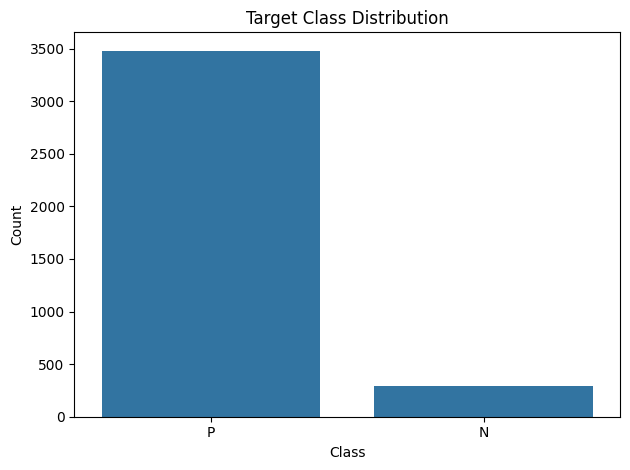

DataFrame head saved to df_head.xlsx
DataFrame statistics saved to df_statistics.xlsx


In [ ]:
print("Dataset shape (rows, columns):", df.shape)

print("\nDataset columns:")
print(df.columns)

print("\nDataset information:")
df.info()

print("\nFirst 5 rows of the dataset:")
display(df.head())

df_head = df.head()

# Split columns into two equal groups
cols_part1 = df_head.columns[:15]
cols_part2 = df_head.columns[15:]

df_part1 = df_head[cols_part1]
df_part2 = df_head[cols_part2]

display(df_part1)
display(df_part2)

print("\nStatistical summary of the dataset:")
summary_stats = df.describe(include="all").T
display(summary_stats.head(30))

# TARGET VARIABLE
target_var = "binaryClass"

# We check if target variable is balanced or unbalanced
print("\nNumber of unique classes in target:", df[target_var].nunique(dropna=False))

print("\nTarget class counts:")
print(df[target_var].value_counts(dropna=False))

print("\nTarget class proportions (%):")
print((df[target_var].value_counts(normalize=True, dropna=False) * 100).round(2))

plt.figure()
sns.countplot(x=target_var, data=df)
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


#Get the head into an excel file for the report
df_head = df.head() # Get the head of the DataFrame


output_path_single = "df_head.xlsx"
df_head.to_excel(output_path_single, index=False)
print(f"DataFrame head saved to {output_path_single}")

#Get the statistical into another excel for the report.

#summary_stats = df.describe().T
#summary_stats.reset_index(inplace=True)
#summary_stats.rename(columns={'index': 'Feature'}, inplace=True)


summary_stats_all= summary_stats.head(30)
output_path_summary= "df_statistics.xlsx"
summary_stats_all.to_excel(output_path_summary, index=True)
print(f"DataFrame statistics saved to {output_path_summary}")

## Missing Values



Missing values summary:


,missing,missing_%
TBG,3772,100.00
T3,769,20.39
T4U,387,10.26
FTI,385,10.21
TSH,369,9.78
TT4,231,6.12
age,1,0.03


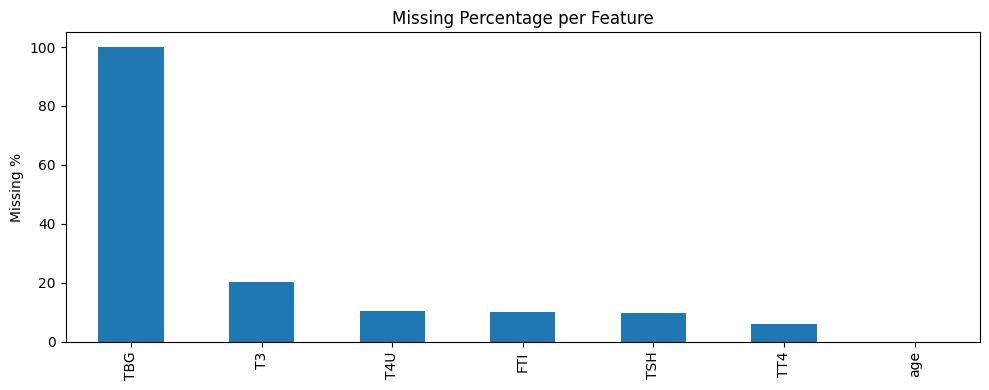

In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({"missing": missing, "missing_%": missing_pct})
missing_table = missing_table[missing_table["missing"] > 0]
print("\nMissing values summary:")
display(missing_table)

# A bar chart showing the missing percentage per feature
plt.figure(figsize=(10,4))
missing_table["missing_%"].plot(kind="bar")
plt.title("Missing Percentage per Feature")
plt.ylabel("Missing %")
plt.tight_layout()
plt.show()


In [ ]:
# TBG feature is fully missing therefore we remove it
if "TBG" in df.columns:
    df = df.drop(columns=["TBG"])


## Convert data types

In [ ]:
numerics = ["age", "TSH", "T3", "TT4", "T4U", "FTI"]

for col in numerics:
    if col in df.columns:
       df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert the true, false columns into 0/1. From the earlier inspection we can see that
# all non-numeric columns are of object type
tf_cols = []

for col in df.columns:
      if df[col].dtype == "object":

          unique_values = set(df[col].dropna().unique())

          if unique_values.issubset({"t","f"}):
             tf_cols.append(col)
print("Columns with only true/false values: ", tf_cols)

for col in tf_cols:
    df[col] = df[col].map({"t": 1, "f": 0})

# Will be useful later on
df["binaryClass_num"] = df["binaryClass"].map({"P": 1, "N": 0})

# Verify
print("\nData types after conversions:")
df.info()

Columns with only true/false values:  ['on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery', 'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'T3 measured', 'TT4 measured', 'T4U measured', 'FTI measured', 'TBG measured']

Data types after conversions:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3772 entries, 0 to 3771
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        3771 non-null   float64
 1   sex                        3772 non-null   string 
 2   on thyroxine               3772 non-null   int64  
 3   query on thyroxine         3772 non-null   int64  
 4   on antithyroid medication  3772 non-null   int64  
 5   sick                       3772 non-null   int64  
 6   pregnant                   3772 non-null   int64  
 

In [ ]:
df["TBG measured"].value_counts()

,count
TBG measured,
0,3772


We see that TBG measured has no information so we need to drop it.

In [ ]:
df = df.drop(columns=["TBG measured"])

### Recompute features

In [ ]:
#categorical = df.select_dtypes(include=["object"]).columns.tolist()
#numeric = df.select_dtypes(include=[np.number]).columns.tolist()

#print("Categorical columns:", categorical)
#print("Numeric columns:", numeric)

######
# We keep the target seperate since its not a feature
# !
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in [target_var]]

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["binaryClass_num"]]

print("Categorical columns:", categorical_cols)
print("Numeric columns:", num_cols)

Categorical columns: ['sex', 'referral source']
Numeric columns: ['age', 'on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery', 'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'TSH', 'T3 measured', 'T3', 'TT4 measured', 'TT4', 'T4U measured', 'T4U', 'FTI measured', 'FTI']


## Univariate numeric plots with histograms

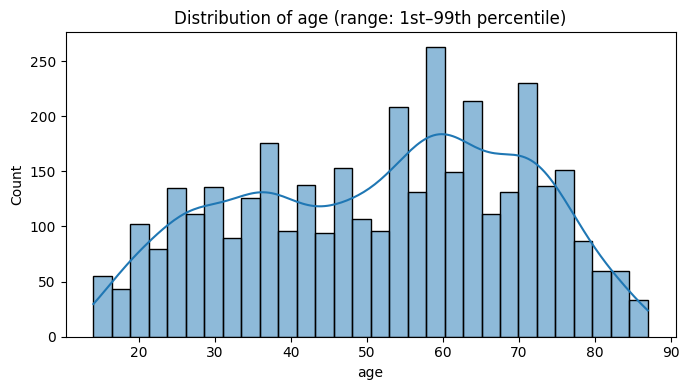

age: plotted range [14.000, 87.000]  |  max=455.000


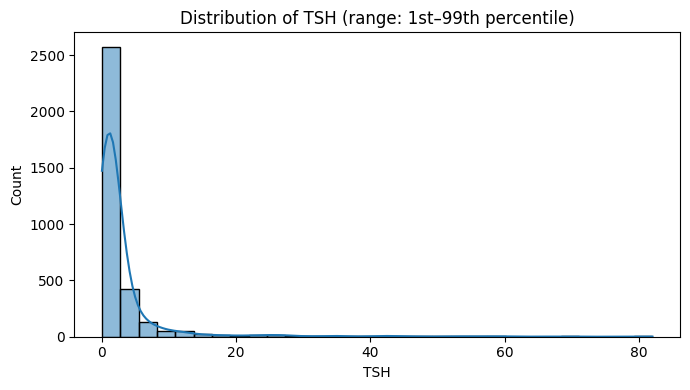

TSH: plotted range [0.005, 85.920]  |  max=530.000


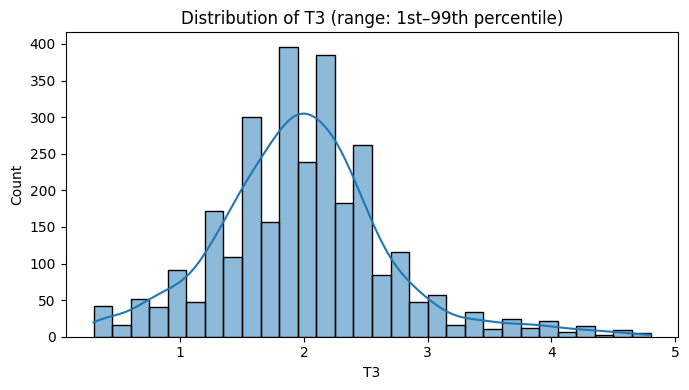

T3: plotted range [0.300, 4.800]  |  max=10.600


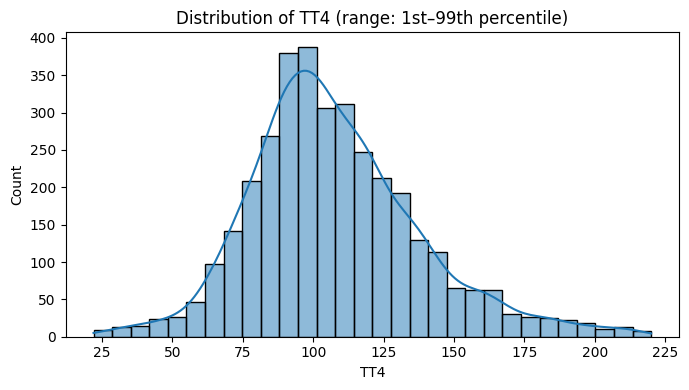

TT4: plotted range [22.000, 221.200]  |  max=430.000


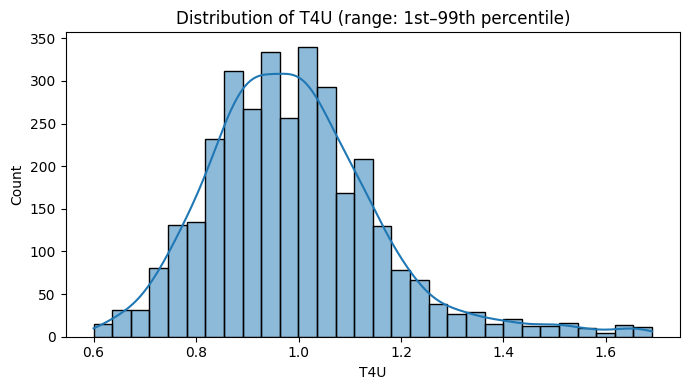

T4U: plotted range [0.600, 1.690]  |  max=2.320


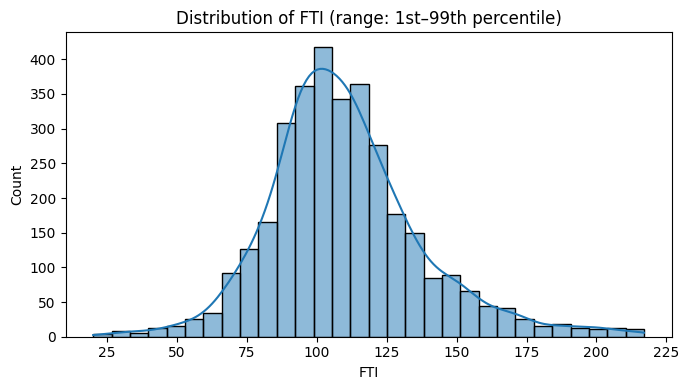

FTI: plotted range [19.860, 217.000]  |  max=395.000


In [ ]:
# These are the ones that are of float64 type, not the 0/1 integer types

num_cols = ["age", "TSH", "T3", "TT4", "T4U", "FTI"]

for col in num_cols:
    x = df[col].dropna()

    # Clip extreme values ONLY for visualization because earlier the range
    # had extreme outliers that affected it
    # 1st–99th percentile keeps the main bulk and removes extreme outliers from the plot.
    low = x.quantile(0.01)
    high = x.quantile(0.99)
    x_clip = x[(x >= low) & (x <= high)]

    plt.figure(figsize=(7,4))

    # seaborn histplot
    sns.histplot(x_clip, bins=30, kde=True)

    plt.title(f"Distribution of {col} (range: 1st–99th percentile)")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # Print clipping range so you can mention it in your report
    print(f"{col}: plotted range [{low:.3f}, {high:.3f}]  |  max={x.max():.3f}")

**Age**
The dataset contains patients across a wide age range, with a higher density in middle-aged and elderly individuals, which is clinically consistent with thyroid disorders being more prevalent in older populations.

**TSH**
TSH exhibits a highly right-skewed distribution, with most patients showing low to moderate values and a small number of extreme elevations, consistent with hypothyroid pathology.

**T3**
T3 values display an approximately normal distribution with mild right skew, suggesting relatively stable physiological ranges for most patients.

**TT4**
TT4 demonstrates a roughly normal distribution, indicating consistent measurement behavior across the population.

**T4U**
T4U shows a narrow distribution with low variance, suggesting limited but potentially discriminative power when combined with other thyroid markers.

**FTI**
FTI exhibits a right-skewed distribution with a long upper tail, reflecting compounded variability from its component measurements.

## Univariate categorical

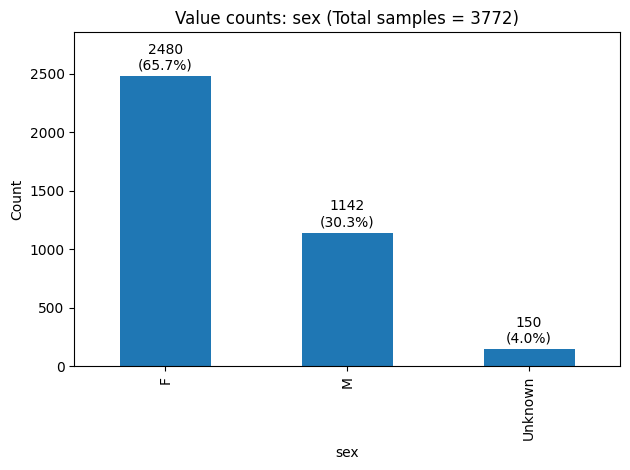


Feature: sex
         count  percentage (%)
sex                           
F         2480       65.747614
M         1142       30.275716
Unknown    150         3.97667
Total     3772           100.0


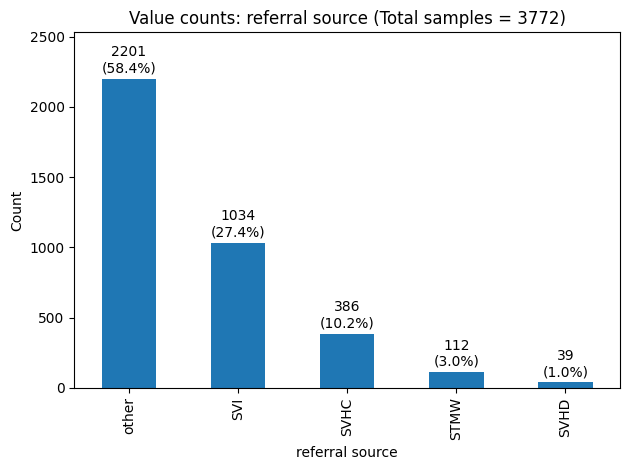


Feature: referral source
                 count  percentage (%)
referral source                       
other             2201       58.351007
SVI               1034       27.412513
SVHC               386       10.233298
STMW               112        2.969247
SVHD                39        1.033934
Total             3772      100.000000


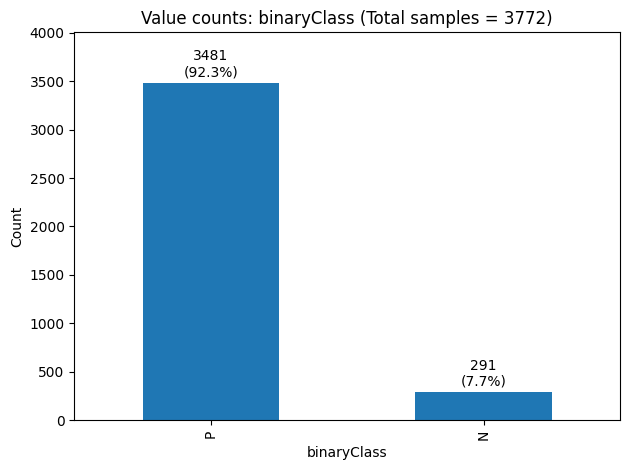


Feature: binaryClass
             count  percentage (%)
binaryClass                       
P             3481        92.28526
N              291         7.71474
Total         3772       100.00000


In [ ]:
# Show value counts for key categorical columns
cat_cols_to_plot = ["sex", "referral source", target_var]

for col in cat_cols_to_plot:
    if col in df.columns:

        counts = df[col].value_counts(dropna=False)
        percentages = df[col].value_counts(normalize=True, dropna=False) * 100

        ax = df[col].value_counts(dropna=False).plot(kind="bar")
        ax.set_title(f"Value counts: {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.set_ylim(0, counts.max() * 1.15)
        for i, (count, pct) in enumerate(zip(counts, percentages)):
            ax.text(i, count + counts.max()*0.01,
              f"{count}\n({pct:.1f}%)",
              ha="center", va="bottom")


        summary = pd.DataFrame({
          "count": counts,
          "percentage (%)": percentages
        })

        summary.loc["Total"] = [counts.sum(), 100]
        ax.set_title(f"Value counts: {col} (Total samples = {counts.sum()})")
        plt.tight_layout()
        plt.show()

        print(f"\nFeature: {col}")
        print(summary)


## Univariate boolean flags (0/1 columns)



In [ ]:
# These are meaningful clinical history flags (already converted to 0/1).
# We plot only a subset so the notebook stays readable.
binary_cols = []
for col in df.columns:
    if df[col].dropna().isin([0, 1]).all() and col not in ["binaryClass_num"]:
        binary_cols.append(col)


# Compute the percentage of 1s for each column to choose those ones that provide the most amount of info
rates = []
for col in binary_cols:
    pct_ones = (df[col]==1).mean() * 100
    rates.append((col, pct_ones))

# Given a tuple (our x) return the second element which is the percentage
rates = sorted(rates, key=lambda x: x[1], reverse=True)

# Shows the top 10
rates[:10]
#Shows all bool percentages where they are 1 ranked in descending manner.
#rates[:30]

for name, pct in rates:
    print(f"{name}: {pct:.4f}%")

TT4 measured: 93.8759%
TSH measured: 90.2174%
FTI measured: 89.7932%
T4U measured: 89.7402%
T3 measured: 79.6129%
on thyroxine: 12.3012%
query hyperthyroid: 6.2831%
query hypothyroid: 6.2036%
psych: 4.8780%
sick: 3.8971%
tumor: 2.5451%
I131 treatment: 1.5642%
pregnant: 1.4051%
thyroid surgery: 1.4051%
query on thyroxine: 1.3256%
on antithyroid medication: 1.1400%
goitre: 0.9014%
lithium: 0.4772%
hypopituitary: 0.0265%


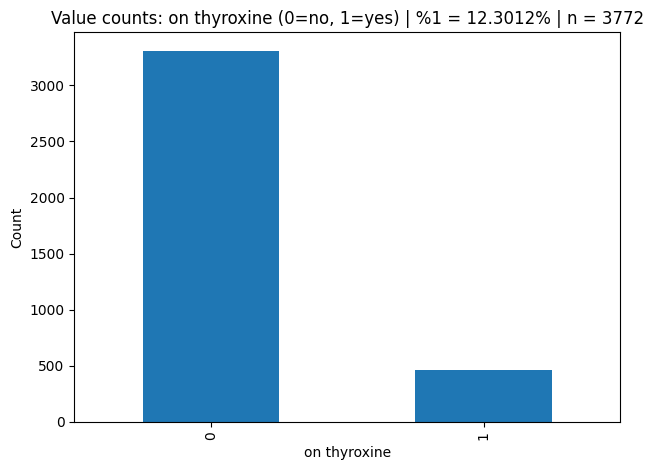

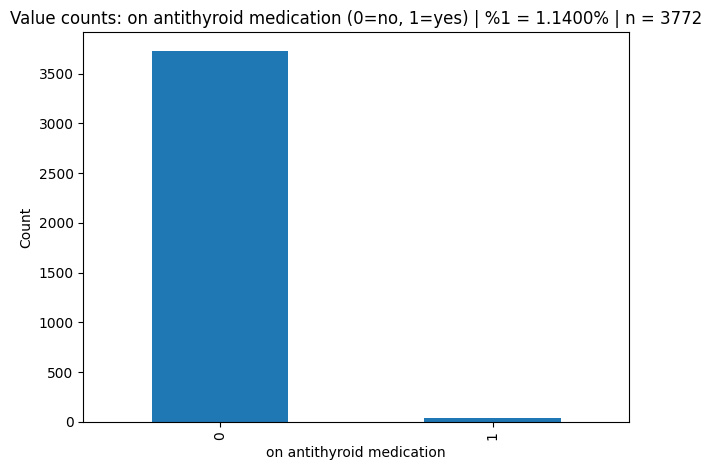

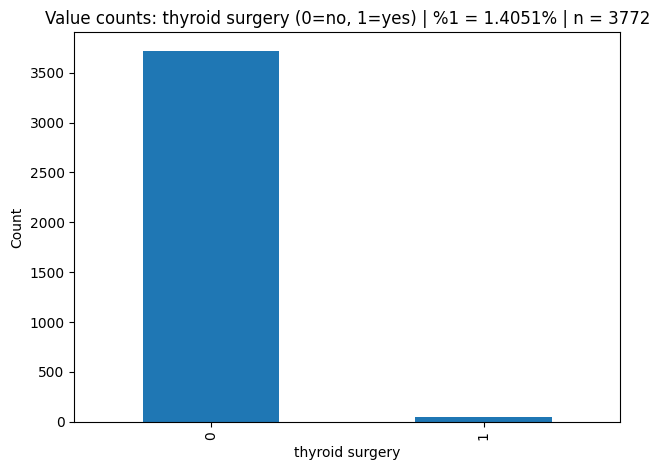

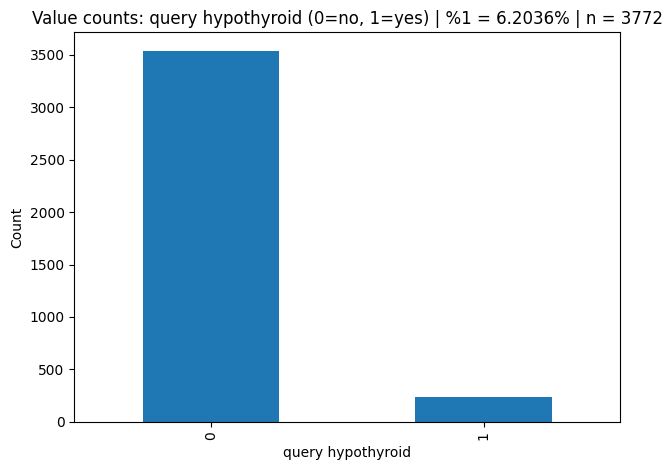

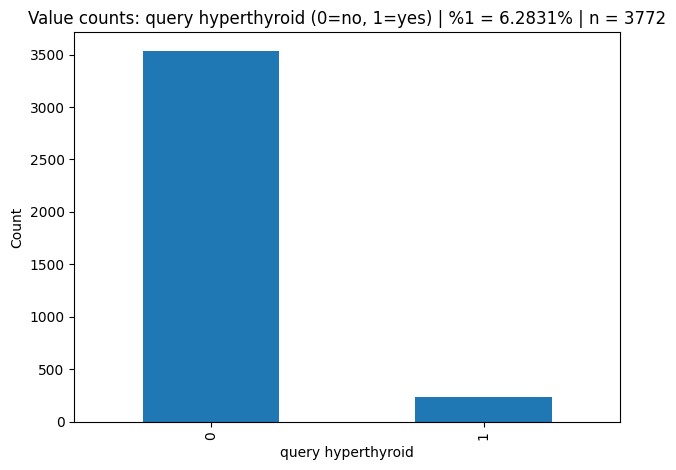

In [ ]:

# Univariate plots for 5 clinically meaningful boolean flags (0=no, 1=yes)
# The other ones that are X .. measured basically indicate if such a lab measurement
# was done or not therefore we chose only the clinical flags
clinical_flags_5 = [
    "on thyroxine",
    "on antithyroid medication",
    "thyroid surgery",
    "query hypothyroid",
    "query hyperthyroid",
]

for col in clinical_flags_5:
    if col in df.columns:
        #ax = df[col].value_counts(dropna=False).sort_index().plot(kind="bar")
        #ax.set_title(f"Value counts: {col} (0=no, 1=yes)")
        #ax.set_xlabel(col)
        #ax.set_ylabel("Count")
        #plt.tight_layout()
        #plt.show()



        pct_ones = (df[col] == 1).mean() * 100
        n_actual = df[col].notna().sum()

        ax = df[col].value_counts(dropna=False).sort_index().plot(kind="bar")

        ax.set_title(f"Value counts: {col} (0=no, 1=yes) | %1 = {pct_ones:.4f}% | n = {n_actual}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")

        plt.tight_layout()
        plt.show()



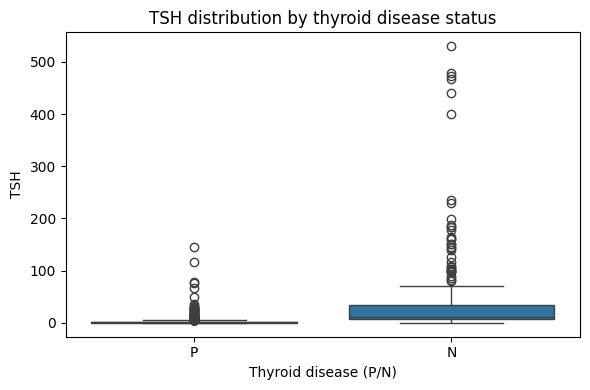

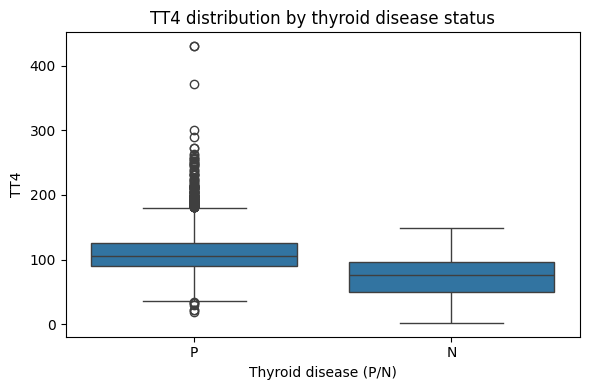

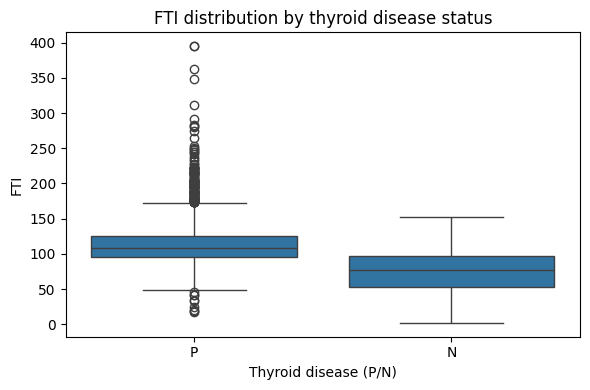

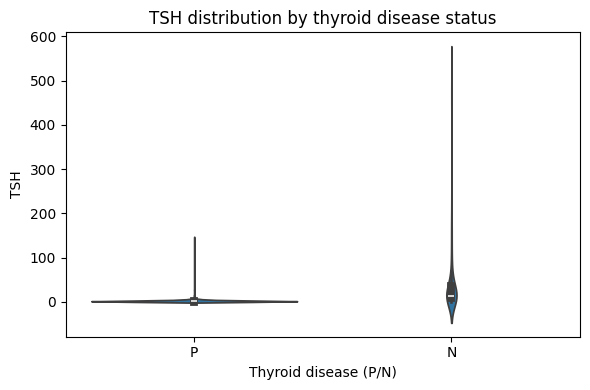

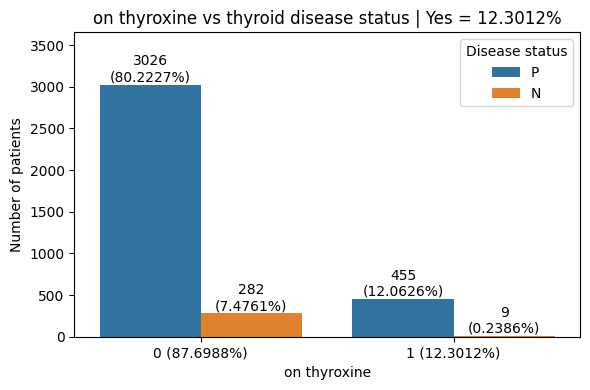

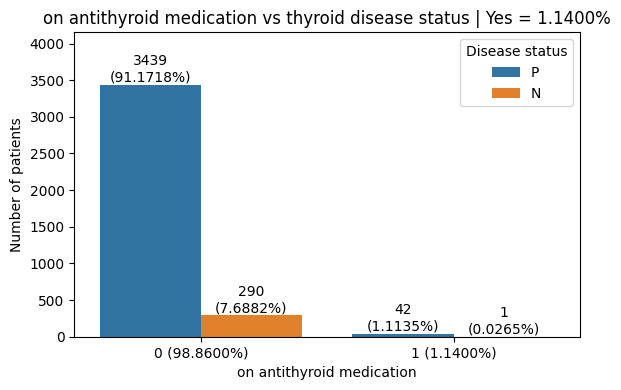

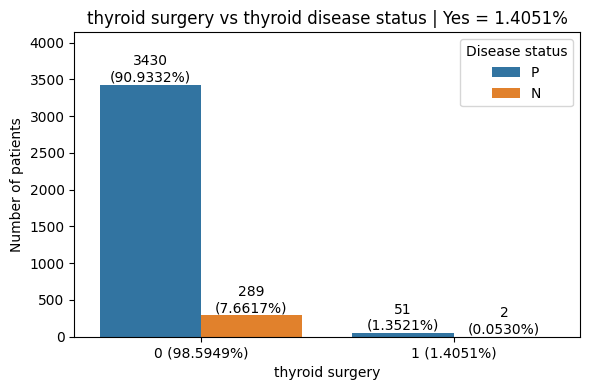

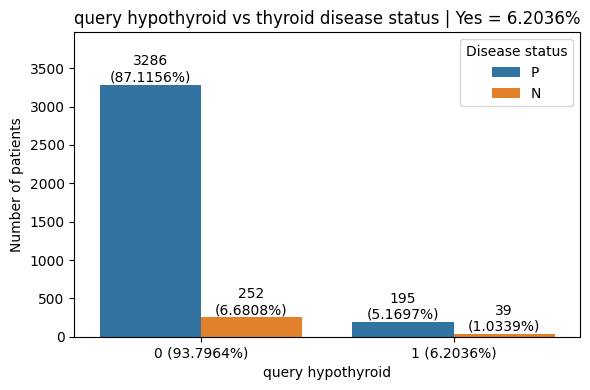

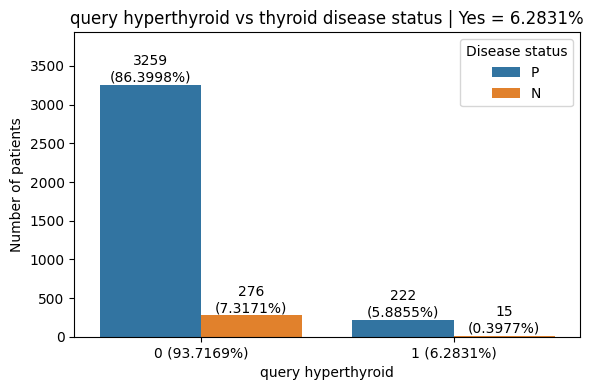

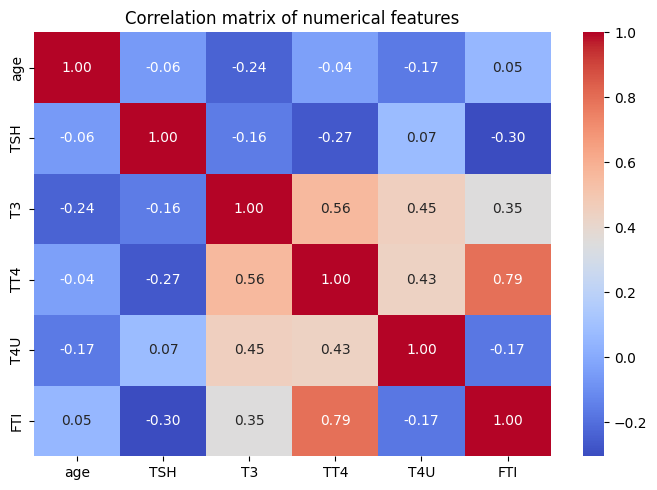


Ranked correlations:
TT4 - FTI: 0.7933
T3 - TT4: 0.5595
T3 - T4U: 0.4541
TT4 - T4U: 0.4346
T3 - FTI: 0.3489
TSH - FTI: -0.3047
TSH - TT4: -0.2674
age - T3: -0.2384
T4U - FTI: -0.1740
age - T4U: -0.1663
TSH - T3: -0.1618
TSH - T4U: 0.0734
age - TSH: -0.0591
age - FTI: 0.0528
age - TT4: -0.0388


In [ ]:
# Numeric features vs Target
# Boxplots that will show whether lab values differ between patients with and without thyroid disease

num_vs_target = ["TSH", "TT4", "FTI"]

for col in num_vs_target:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.boxplot(x="binaryClass", y=col, data=df)
        plt.title(f"{col} distribution by thyroid disease status")
        plt.xlabel("Thyroid disease (P/N)")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

# It shows the distribution and density of TSH values across disease classes
#The below commented code, is covered in the above for loop for TSH
plt.figure(figsize=(6,4))
sns.violinplot(x="binaryClass", y="TSH", data=df)
plt.title("TSH distribution by thyroid disease status")
plt.xlabel("Thyroid disease (P/N)")
plt.ylabel("TSH")
plt.tight_layout()
plt.show()

# Count plots to explore relationships between categorical clinical features
#and thyroid disease status
cat_vs_target = ["on thyroxine",
                 "on antithyroid medication",
                 "thyroid surgery",
                 "query hypothyroid",
                 "query hyperthyroid",]


for col in cat_vs_target:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        #sns.countplot(x=col, hue="binaryClass", data=df)


        #plt.title(f"{col} vs thyroid disease status")
        #plt.xlabel(col)
        #plt.ylabel("Count")
        #plt.legend(title="Disease status")

        ax = sns.countplot(
            x=col,
            hue="binaryClass",
            data=df,
            #stat="percent"
        )

        total = len(df)
        #Positive percentage- 1s %
        yes_pct = (df[col] == 1).mean() * 100

        # annotate bars with count + percentage
        for p in ax.patches:
            count = int(p.get_height())
            # Skip empty bars- one wrong visual was shown on the graph below if
            #fixes it
            if count == 0:
                continue
            pct = (count / total) * 100
            no_pct = 100 - yes_pct

            ax.text(
                p.get_x() + p.get_width()/2,
                count,
                f"{count}\n({pct:.4f}%)",
                ha="center",
                va="bottom"
            )

        # add headroom so labels stay inside the plot
        ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
        ax.set_xticks([0, 1])
        ax.set_xticklabels([
            f"0 ({no_pct:.4f}%)",
            f"1 ({yes_pct:.4f}%)"
        ])
        ax.set_title(f"{col} vs thyroid disease status | Yes = {yes_pct:.4f}%")
        ax.set_xlabel(col)
        ax.set_ylabel("Number of patients")
        ax.legend(title="Disease status")


        plt.tight_layout()
        plt.show()



# Correlation heatmap for numerical lab values
num_cols = ["age", "TSH", "T3", "TT4", "T4U", "FTI"]

corr = df[num_cols].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix of numerical features")
plt.tight_layout()
plt.show()

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))  # keep upper triangle only
        .stack()
)
corr_pairs = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)

print("\nRanked correlations:")
for (var1, var2), value in corr_pairs.items():
    print(f"{var1} - {var2}: {value:.4f}")

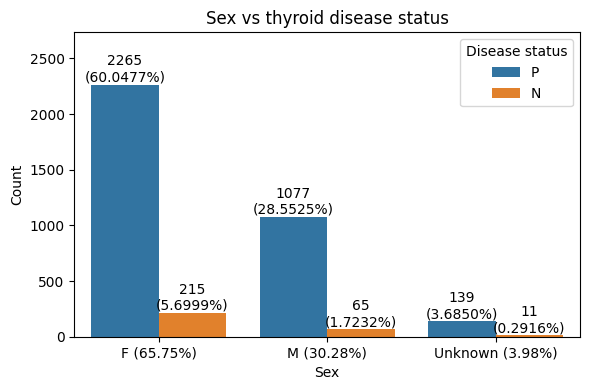

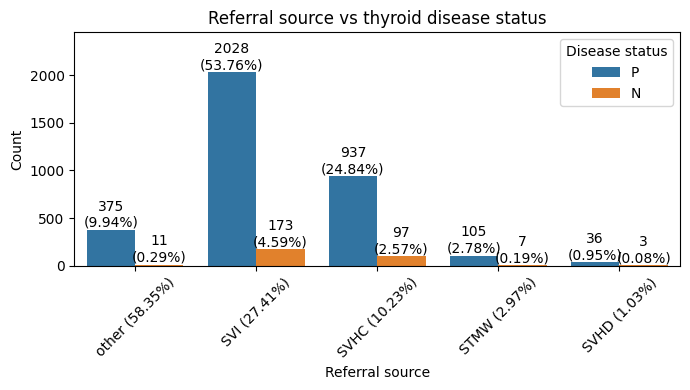

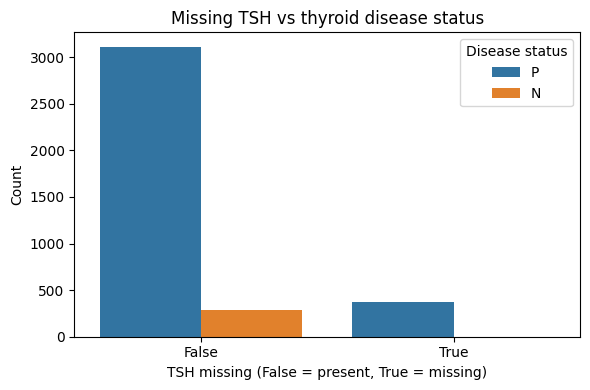

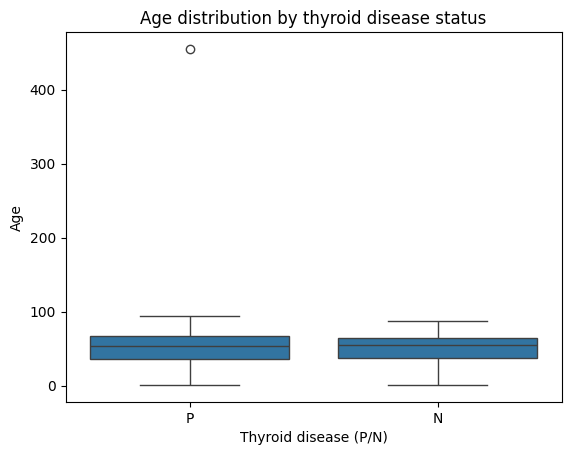

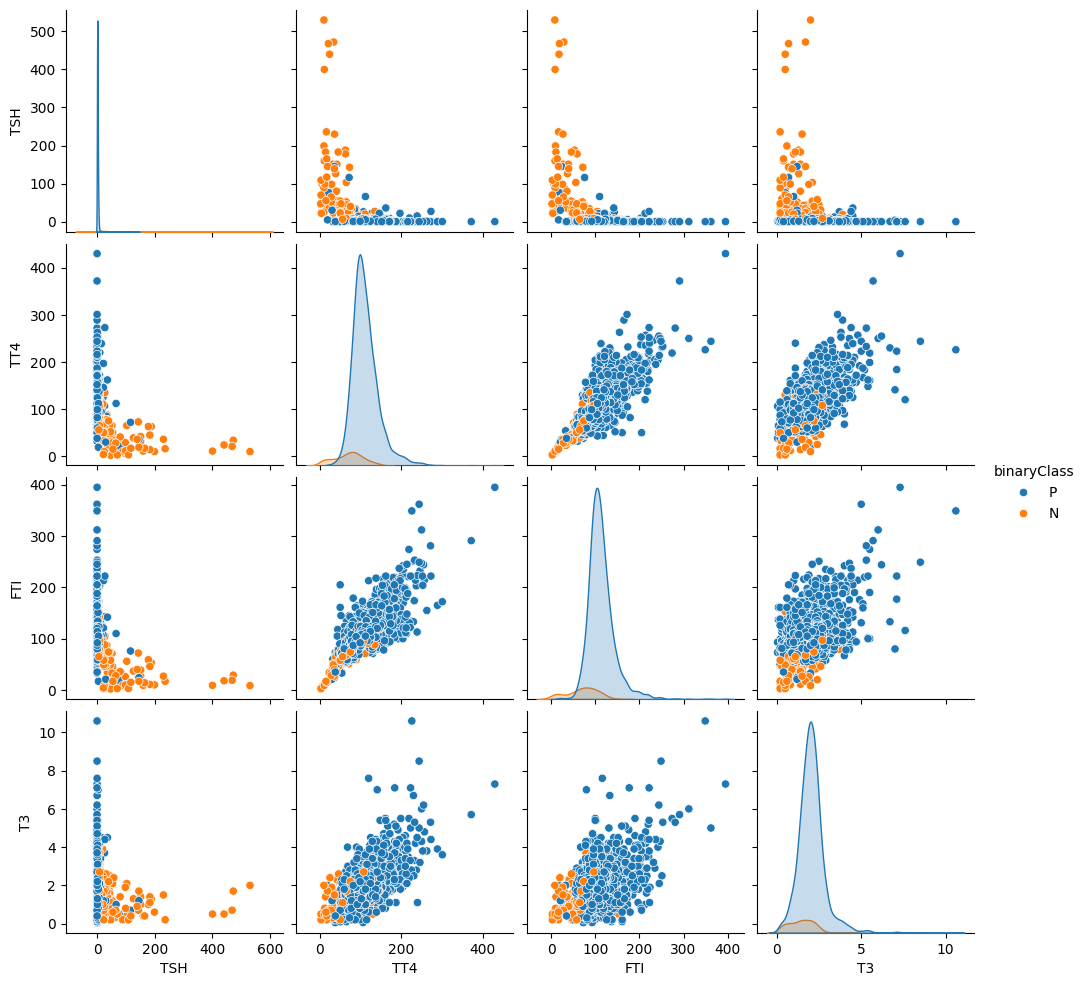

In [ ]:
# Sex vs disease
plt.figure(figsize=(6,4))


#sns.countplot(x="sex", hue="binaryClass", data=df)
ax = sns.countplot(x="sex", hue="binaryClass", data=df)

total = len(df)
sex_pct = df["sex"].value_counts(normalize=True) * 100

for p in ax.patches:
    count = int(p.get_height())
    if count == 0:
        continue

    pct = (count / total) * 100

    ax.text(
        p.get_x() + p.get_width()/2,
        count,
        f"{count}\n({pct:.4f}%)",
        ha="center",
        va="bottom"
    )

ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
ax.set_xticks(range(len(sex_pct)))
ax.set_xticklabels([f"{k} ({v:.2f}%)" for k,v in sex_pct.items()])

plt.title("Sex vs thyroid disease status")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(title="Disease status")
plt.tight_layout()
plt.show()

# Referral source vs disease status
plt.figure(figsize=(7,4))
#sns.countplot(x="referral source", hue="binaryClass", data=df)

ax = sns.countplot(x="referral source", hue="binaryClass", data=df)

total = len(df)
ref_pct = df["referral source"].value_counts(normalize=True) * 100

for p in ax.patches:
    count = int(p.get_height())
    if count == 0:
        continue

    pct = (count / total) * 100

    ax.text(
        p.get_x() + p.get_width()/2,
        count,
        f"{count}\n({pct:.2f}%)",
        ha="center",
        va="bottom"
    )

ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
ax.set_xticks(range(len(ref_pct)))
ax.set_xticklabels([f"{k} ({v:.2f}%)" for k,v in ref_pct.items()], rotation=45)

plt.title("Referral source vs thyroid disease status")
plt.xlabel("Referral source")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Disease status")
plt.tight_layout()
plt.show()

# Missingness vs target
plt.figure(figsize=(6,4))
sns.countplot(
    x=df["TSH"].isna(),
    hue=df["binaryClass"]
)
plt.title("Missing TSH vs thyroid disease status")
plt.xlabel("TSH missing (False = present, True = missing)")
plt.ylabel("Count")
plt.legend(title="Disease status")
plt.tight_layout()
plt.show()

# Age vs Target
sns.boxplot(x="binaryClass", y="age", data=df)
plt.title("Age distribution by thyroid disease status")
plt.xlabel("Thyroid disease (P/N)")
plt.ylabel("Age")
plt.show()

# Pairplot of numerical features
sns.pairplot(
    df[["TSH","TT4","FTI", "T3","binaryClass"]].dropna(),
    hue="binaryClass",
    diag_kind="kde"
)

# **Data pre-processing**



**Handle Duplicates**

In [ ]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 61


In [ ]:
# Remove duplicate rows and keep the first occurrence
df = df.drop_duplicates()

# Check
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:

# Missing values per feature
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

missing_pct = (df.isnull().mean() * 100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_%": missing_pct.round(2)
})

print("\nMissing values summary (per feature):")
display(missing_summary)


# Rows with the most missing values

top_k = 10
total_features = df.shape[1]

row_missing_counts = df.isnull().sum(axis=1)

top_missing_rows = row_missing_counts.sort_values(ascending=False).head(top_k)

rows_with_most_missing = pd.DataFrame({
    "row_index": top_missing_rows.index,
    "missing_count": top_missing_rows.values,
    "missing_out_of_total": [f"{c} / {total_features}" for c in top_missing_rows.values]
})

print(f"\nTop {top_k} rows with the most missing values:")
display(rows_with_most_missing)

# Near-constant columns (>99% dominant)

print("\nNear-Constant Columns (dominant value > 99%)")
low_variance_cols = []

for col in df.columns:
    vc = df[col].value_counts(normalize=True, dropna=False)
    if len(vc) > 0:
        top_freq = vc.iloc[0]
        if top_freq > 0.99:
            low_variance_cols.append((col, round(top_freq * 100, 2), vc.index[0]))

if not low_variance_cols:
    print("No near-constant columns found.")
else:
    display(pd.DataFrame(low_variance_cols, columns=["Column", "Dominant %", "Dominant value"])
            .sort_values("Dominant %", ascending=False))


# Highly correlated numeric features Here we may have an issue with the code
print("\nHighly Correlated Feature Pairs (>|0.9|):")

num_cols = [c for c in ["age", "TSH", "T3", "TT4", "T4U", "FTI"] if c in df.columns]

if len(num_cols) < 2:
    print("Not enough numeric columns to compute correlations.")
else:
    corr_matrix = df[num_cols].corr().abs()

    high_corr = []
    cols = corr_matrix.columns

    for i in range(len(cols)):
        for j in range(i):
            corr_val = corr_matrix.iloc[i, j]
            if corr_val > 0.9:
                high_corr.append((cols[i], cols[j], round(corr_val, 3)))

    if not high_corr:
        print("No highly correlated feature pairs found")
    else:
        display(pd.DataFrame(high_corr, columns=["Feature 1", "Feature 2", "Correlation"]))






Missing values summary (per feature):


,missing_count,missing_%
T3,709,19.11
T4U,327,8.81
FTI,325,8.76
TSH,309,8.33
TT4,171,4.61
age,1,0.03



Top 10 rows with the most missing values:


,row_index,missing_count,missing_out_of_total
0,39,5,5 / 29
1,3767,5,5 / 29
2,1006,5,5 / 29
3,1012,5,5 / 29
4,3702,5,5 / 29
5,1077,5,5 / 29
6,929,5,5 / 29
7,72,5,5 / 29
8,2380,5,5 / 29
9,2395,5,5 / 29



Near-Constant Columns (dominant value > 99%)


,Column,Dominant %,Dominant value
2,hypopituitary,99.97,0
0,lithium,99.51,0
1,goitre,99.08,0



Highly Correlated Feature Pairs (>|0.9|):
No highly correlated feature pairs found


# **Handle the incorrect values of age**

In [ ]:
MAX_AGE = 120

# We replace the invalid ages with NaN
df.loc[(df["age"] < 0) | (df["age"] > MAX_AGE), "age"] = np.nan

print("Max age after fix:", df["age"].max())
print("Missing ages(NaN):", df["age"].isna().sum())


Max age after fix: 94.0
Missing ages(NaN): 2


# **Train-Test Splitting**

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["binaryClass", "binaryClass_num"])
y = df["binaryClass_num"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))

Train shape: (2968, 27)
Test shape: (743, 27)
Train class balance:
 binaryClass_num
1    0.921496
0    0.078504
Name: proportion, dtype: float64
Test class balance:
 binaryClass_num
1    0.921938
0    0.078062
Name: proportion, dtype: float64


In [ ]:
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numeric:", num_features)
print("Categorical:", cat_features)


Numeric: ['age', 'on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery', 'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'TSH', 'T3 measured', 'T3', 'TT4 measured', 'TT4', 'T4U measured', 'T4U', 'FTI measured', 'FTI']
Categorical: ['sex', 'referral source']


# Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer


categorical_cols = ["sex", "referral source"]
continuous_cols = ["age", "TSH", "T3", "TT4", "T4U", "FTI"]

tsh_col = ["TSH"]
other_cont_cols = [c for c in continuous_cols if c != "TSH"]

# Shared categorical pipeline
cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


## Check Skewness

In [ ]:
print("Skewness on training set")
skew_raw = X_train[continuous_cols].skew(numeric_only=True)
display(skew_raw.sort_values(ascending=False))

# Justify log-transform for TSH
tsh_train = pd.to_numeric(X_train["TSH"], errors="coerce")
tsh_log = np.log1p(tsh_train)

print("\nTSH skewness before log1p:", skew_raw["TSH"])
print("TSH skewness after  log1p :", pd.Series(tsh_log).skew(skipna=True))

Skewness on training set


,0
TSH,13.414424
T3,1.784232
T4U,1.289831
FTI,1.259942
TT4,1.089907
age,-0.206371



TSH skewness before log1p: 13.414424496707843
TSH skewness after  log1p : 1.9491279193039008


## Check outliers

In [ ]:
# Outlier rate (IQR rule)
outlier_rates = {}

for c in continuous_cols:
    s = pd.to_numeric(X_train[c], errors="coerce").dropna()
    if s.empty:
        outlier_rates[c] = np.nan
        continue

    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        outlier_rates[c] = 0.0
        continue

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_rates[c] = ((s < lower) | (s > upper)).mean()

outlier_rates = pd.Series(outlier_rates).sort_values(ascending=False)
outlier_rates.name = "Outlier rate"
display(outlier_rates)

,Outlier rate
TSH,0.108327
T3,0.068022
FTI,0.057934
TT4,0.057244
T4U,0.046881
age,0.000000


# **Dataset Version 0**

## **Creating Version 0**

In [ ]:
features_to_drop = ["age", "TSH", "TT4", "FTI"]

df_v0 = df.dropna(subset=features_to_drop).copy()

print("Original dataset shape:", df.shape)
print("V0 dataset shape:", df_v0.shape)
print("Rows removed:", df.shape[0] - df_v0.shape[0])

Original dataset shape: (3711, 29)
V0 dataset shape: (3222, 29)
Rows removed: 489


In [ ]:
# we define the features and the target
X_v0 = df_v0.drop(columns=["binaryClass", "binaryClass_num"])
y_v0 = df_v0["binaryClass_num"]

In [ ]:
# Train/test splitting
from sklearn.model_selection import train_test_split

X_v0_train, X_v0_test, y_v0_train, y_v0_test = train_test_split(X_v0,y_v0,test_size=0.2,random_state=42,stratify=y_v0)

print("V0 train shape:", X_v0_train.shape)
print("V0 test shape:", X_v0_test.shape)
print("Train class balance:\n", y_v0_train.value_counts(normalize=True))

V0 train shape: (2577, 27)
V0 test shape: (645, 27)
Train class balance:
 binaryClass_num
1    0.917346
0    0.082654
Name: proportion, dtype: float64


In [ ]:
# Categorical columns
categorical_columns_v0 = X_v0_train.select_dtypes(include=["object", "string"]).columns.tolist()
print("Categorical columns in V0:", categorical_columns_v0)

Categorical columns in V0: ['sex', 'referral source']


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

num_cols_v0 = X_v0_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns_v0 = X_v0_train.select_dtypes(include=["object", "string"]).columns.tolist()

num_pipe_v0 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipe_v0 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_v0 = ColumnTransformer(
    transformers=[
        ("num", num_pipe_v0, num_cols_v0),
        ("cat", cat_pipe_v0, categorical_columns_v0),
    ]
)

In [ ]:
X_v0_train_proc = preprocess_v0.fit_transform(X_v0_train)
X_v0_test_proc  = preprocess_v0.transform(X_v0_test)

Xtr0 = X_v0_train_proc.toarray() if hasattr(X_v0_train_proc, "toarray") else X_v0_train_proc
Xte0 = X_v0_test_proc.toarray()  if hasattr(X_v0_test_proc, "toarray")  else X_v0_test_proc

print("V0 (unscaled) shapes (train/test):", Xtr0.shape, Xte0.shape)
print("NaNs in X_train_v0:", np.isnan(Xtr0).sum())
print("NaNs in X_test_v0 :", np.isnan(Xte0).sum())

V0 (unscaled) shapes (train/test): (2577, 33) (645, 33)
NaNs in X_train_v0: 0
NaNs in X_test_v0 : 0


In [ ]:
from sklearn.preprocessing import StandardScaler

preprocess_v0_scaled = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols_v0),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_columns_v0),
    ]
)

X_v0_train_scaled = preprocess_v0_scaled.fit_transform(X_v0_train)
X_v0_test_scaled  = preprocess_v0_scaled.transform(X_v0_test)

Xtr0s = X_v0_train_scaled.toarray() if hasattr(X_v0_train_scaled, "toarray") else X_v0_train_scaled
Xte0s = X_v0_test_scaled.toarray()  if hasattr(X_v0_test_scaled, "toarray")  else X_v0_test_scaled

print("V0 (scaled) shapes (train/test):", Xtr0s.shape, Xte0s.shape)
print("NaNs in X_train_v0_scaled:", np.isnan(Xtr0s).sum())
print("NaNs in X_test_v0_scaled :", np.isnan(Xte0s).sum())

V0 (scaled) shapes (train/test): (2577, 33) (645, 33)
NaNs in X_train_v0_scaled: 0
NaNs in X_test_v0_scaled : 0


In [ ]:
# Missing values per feature in V0
missing_v0 = df_v0.isna().sum()
missing_v0 = missing_v0[missing_v0 > 0].sort_values(ascending=False)

missing_pct_v0 = (missing_v0 / len(df_v0) * 100).round(2)

missing_summary_v0 = pd.DataFrame({
    "missing_count": missing_v0,
    "missing_%": missing_pct_v0
})

print("Missing values per feature in V0:")
display(missing_summary_v0)

Missing values per feature in V0:


,missing_count,missing_%
T3,472,14.65
T4U,1,0.03


# **Dataset Version 1**

- Apply SimpleImputer (median) on continuous lab features (age, TSH, T3, TT4, T4U, FTI)

- Apply log1p transform on TSH to reduce skewness

- Apply SimpleImputer (most_frequent) + OneHotEncoder on categorical features (sex, referral source)

- Keep all binary clinical flags (0/1) unchanged via passthrough

- **No scaling ideal for tree-based models**

In [ ]:
# Unscaled Pipeline
tsh_v1 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
])

cont_v1 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

preprocess_v1 = ColumnTransformer(
    transformers=[
        ("tsh", tsh_v1, tsh_col),
        ("cont", cont_v1, other_cont_cols),
        ("cat", cat_pipe, categorical_cols),
    ],
    remainder="passthrough"
)

X_train_v1 = preprocess_v1.fit_transform(X_train)
X_test_v1  = preprocess_v1.transform(X_test)

print("V1 shapes (train/test):", X_train_v1.shape, X_test_v1.shape)

# Check for missing values
Xtr1 = X_train_v1.toarray() if hasattr(X_train_v1, "toarray") else X_train_v1
Xte1 = X_test_v1.toarray()  if hasattr(X_test_v1, "toarray")  else X_test_v1
print("NaNs in X_train_v1:", np.isnan(Xtr1).sum())
print("NaNs in X_test_v1 :", np.isnan(Xte1).sum())

V1 shapes (train/test): (2968, 33) (743, 33)
NaNs in X_train_v1: 0
NaNs in X_test_v1 : 0


**Handle Missing Values**





In [ ]:
# # Numerical Features
# from sklearn.impute import SimpleImputer

# # we use the median to replace the missing values
# num_imputer_V1 = SimpleImputer(strategy="median")
# num_imputer_V1.fit(X_train_V1[num_features])

# # we apply imputation on both training and test datasets
# X_train_V1[num_features] = num_imputer_V1.transform(X_train_V1[num_features])
# X_test_V1[num_features]  = num_imputer_V1.transform(X_test_V1[num_features])

# # Categorical Features
# # we use the the most frequent to replace the missing values
# cat_imputer_V1 = SimpleImputer(strategy="most_frequent")
# cat_imputer_V1.fit(X_train_V1[cat_features])

# X_train_V1[cat_features] = cat_imputer_V1.transform(X_train_V1[cat_features])
# X_test_V1[cat_features]  = cat_imputer_V1.transform(X_test_V1[cat_features])

# # we check that there are no missing values
# print("Missing values in X_train_V1:")
# display(X_train_V1.isnull().sum()[X_train_V1.isnull().sum() > 0])

# print("Missing values in X_test_V1:")
# display(X_test_V1.isnull().sum()[X_test_V1.isnull().sum() > 0])





# Dataset Version 2

- Median imputation on continuous lab features (age, TSH, T3, TT4, T4U, FTI)

- Log transform on TSH using log1p (to reduce skewness)

- Standardization (StandardScaler) on continuous lab features

- Most-frequent imputation + One-Hot Encoding for categorical features (sex, referral source)

- All binary clinical flags (0/1) remain unchanged via passthrough

In [ ]:
tsh_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler()),
])

cont_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocess_v2 = ColumnTransformer(
    transformers=[
        ("tsh", tsh_scaled, tsh_col),
        ("cont", cont_scaled, other_cont_cols),
        ("cat", cat_pipe, categorical_cols),
    ],
    remainder="passthrough"
)

X_train_v2 = preprocess_v2.fit_transform(X_train)
X_test_v2  = preprocess_v2.transform(X_test)

print("V2 shapes:", X_train_v2.shape, X_test_v2.shape)

# Check for missing values
# If output is sparse, convert to array for the NaN check
Xtr2 = X_train_v2.toarray() if hasattr(X_train_v2, "toarray") else X_train_v2
Xte2 = X_test_v2.toarray()  if hasattr(X_test_v2, "toarray")  else X_test_v2

print("NaNs in X_train_v2:", np.isnan(Xtr2).sum())
print("NaNs in X_test_v2 :", np.isnan(Xte2).sum())

V2 shapes: (2968, 33) (743, 33)
NaNs in X_train_v2: 0
NaNs in X_test_v2 : 0


# Dataset Version 3

- Apply Version 2 preprocessing

- Apply SMOTE on the training set only

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_v3, y_train_v3 = smote.fit_resample(X_train_v2, y_train)
X_test_v3, y_test_v3 = X_test_v2, y_test


# Check for missing values
Xtr3 = X_train_v3.toarray() if hasattr(X_train_v3, "toarray") else X_train_v3
Xte3 = X_test_v3.toarray()  if hasattr(X_test_v3, "toarray")  else X_test_v3

print("\nNaNs in X_train_v3:", np.isnan(Xtr3).sum())
print("NaNs in X_test_v3 :", np.isnan(Xte3).sum())


NaNs in X_train_v3: 0
NaNs in X_test_v3 : 0


# Dataset Version 4

- Apply Sequential Forward Selection (SFS)

- Use AdaBoostClassifier as the estimator inside SFS

- Optimize using weighted F1-score (appropriate for imbalanced classes)

- Select the best subset of features


[Parallel(n_jobs=1)]: Done  33 out of  33 | elapsed:   13.2s finished

[2026-04-01 14:10:26] Features: 1/20 -- score: 0.9792939971116882[Parallel(n_jobs=1)]: Done  32 out of  32 | elapsed:   13.3s finished

[2026-04-01 14:10:40] Features: 2/20 -- score: 0.989399938521828[Parallel(n_jobs=1)]: Done  31 out of  31 | elapsed:   13.0s finished

[2026-04-01 14:10:53] Features: 3/20 -- score: 0.9919424652519874[Parallel(n_jobs=1)]: Done  30 out of  30 | elapsed:   13.3s finished

[2026-04-01 14:11:06] Features: 4/20 -- score: 0.9942747491381572[Parallel(n_jobs=1)]: Done  29 out of  29 | elapsed:   12.9s finished

[2026-04-01 14:11:19] Features: 5/20 -- score: 0.9946219047592367[Parallel(n_jobs=1)]: Done  28 out of  28 | elapsed:   13.1s finished

[2026-04-01 14:11:32] Features: 6/20 -- score: 0.9946219047592367[Parallel(n_jobs=1)]: Done  27 out of  27 | elapsed:   13.3s finished

[2026-04-01 14:11:45] Features: 7/20 -- score: 0.9946219047592367[Parallel(n_jobs=1)]: Done  26 out of  26 | elaps

Best subset score (weighted F1): 0.995
Best feature indices: (0, 3, 5, 14, 19)


[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    6.2s finished

[2026-04-01 14:13:52] Features: 20/20 -- score: 0.9946219047592367

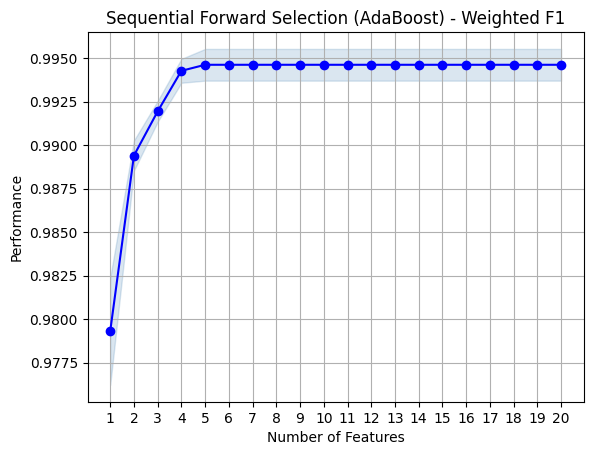

V4 shapes: (2968, 5) (743, 5)


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import make_scorer, f1_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs


ada = AdaBoostClassifier(random_state=42)
f1_weighted = make_scorer(f1_score, average="weighted")

sfs = SFS(
    estimator=ada,
    k_features=(5, 20),
    forward=True,
    floating=False,
    scoring=f1_weighted,
    cv=3,          # if its not slow we can increase to 10
    n_jobs=1,
    verbose=2
)

sfs.fit(X_train_v2, y_train)

print(f"Best subset score (weighted F1): {sfs.k_score_:.3f}")
print("Best feature indices:", sfs.k_feature_idx_)

# Build V4 datasets from selected indices
selected_idx_v4 = list(sfs.k_feature_idx_)
X_train_v4 = X_train_v2[:, selected_idx_v4]
X_test_v4  = X_test_v2[:, selected_idx_v4]

# Plot SFS performance
fig = plot_sfs(sfs.get_metric_dict(), kind="std_err")
plt.title("Sequential Forward Selection (AdaBoost) - Weighted F1")
plt.grid(True)
plt.show()

print("V4 shapes:", X_train_v4.shape, X_test_v4.shape)

# Dataset Version 5

- *Source:* https://link.springer.com/article/10.1186/s43067-023-00101-5
- Apply embedded feature selection using L1-regularized Logistic Regression (LASSO-style)

- Fit the L1 Logistic Regression model on the training data

- Use SelectFromModel with threshold "mean" to keep the most informative features

- Create reduced datasets by transforming the V2 matrices:

  - X_train_v5 = selector.transform(X_train_v2)

  - X_test_v5 = selector.transform(X_test_v2)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

l1_lr = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.5,
    max_iter=2000,
    random_state=42
)

selector = SelectFromModel(l1_lr, threshold="mean")
selector.fit(X_train_v2, y_train)

X_train_v5 = selector.transform(X_train_v2)
X_test_v5  = selector.transform(X_test_v2)

print("V5 selected features:", X_train_v5.shape[1])
print("V5 shapes:", X_train_v5.shape, X_test_v5.shape)

V5 selected features: 3
V5 shapes: (2968, 3) (743, 3)


# Dataset Version 6

- Apply SimpleImputer (median) on continuous lab features (age, TSH, T3, TT4, T4U, FTI)

- Apply log1p transform on TSH to reduce extreme right-skewness

- Apply RobustScaler on continuous lab features (and on TSH after log transform)

- Apply SimpleImputer (most_frequent) + One-Hot Encoding on categorical features (sex, referral source)

- Keep all binary clinical flags (0/1) unchanged via passthrough

**Note**: Through the outlier analysis on the training set using IQR rule we have non-negligible outlier rates such as TSH ≈ 10.8%, and others around 5–7%. RobustScaler scales using the median and IQR thus is less sensitive to outliers.

In [ ]:
from sklearn.preprocessing import RobustScaler
# V6 is like V2 but with Robust Scaling

tsh_robust = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", RobustScaler()),
])

cont_robust = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

preprocess_v6 = ColumnTransformer(
    transformers=[
        ("tsh", tsh_robust, tsh_col),
        ("cont", cont_robust, other_cont_cols),
        ("cat", cat_pipe, categorical_cols),
    ],
    remainder="passthrough"
)

X_train_v6 = preprocess_v6.fit_transform(X_train)
X_test_v6  = preprocess_v6.transform(X_test)

print("V6 shapes (train/test):", X_train_v6.shape, X_test_v6.shape)

# Optional NaN check (handles sparse)
import numpy as np
Xtr6 = X_train_v6.toarray() if hasattr(X_train_v6, "toarray") else X_train_v6
Xte6 = X_test_v6.toarray()  if hasattr(X_test_v6, "toarray")  else X_test_v6
print("NaNs in X_train_v6:", np.isnan(Xtr6).sum())
print("NaNs in X_test_v6 :", np.isnan(Xte6).sum())

V6 shapes (train/test): (2968, 33) (743, 33)
NaNs in X_train_v6: 0
NaNs in X_test_v6 : 0


# Evaluation Setup


Before we benchmark the models, we first organize every usable dataset version in one place and define one common evaluation setup. We prepare an evaluation setup that:

- keeps all dataset versions together,
- checks their shapes, missing values, and class balance,
- uses the same cross-validation strategy and metrics for every model-version combination, and
- keeps the current matrices for screening only.




In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


# Some preprocessing outputs are sparse like ater one-hot encoding,
# Others are already dense. This is done to convert
# into to a regular NumPy array so shape and NaN checks can be done consistently.
def to_dense_array(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)

# This is used for the ensemble stacking model. The estimators are Logistic Regression, SVM, Random Forest
def build_default_stacking_model():
    base_estimators = [
        ("lr", LogisticRegression(max_iter=2000, random_state=42)),
        ("rf", RandomForestClassifier(random_state=42)),
        ("svm", SVC()),
    ]
    final_estimator = LogisticRegression(max_iter=2000, random_state=42)

    return StackingClassifier(
        estimators=base_estimators,
        final_estimator=final_estimator,
        cv=3,
        n_jobs=1,
    )



#Here we place all our generated datasets into one storage for better handling and cleaner coding
dataset_versions = {
    "V0_Unscaled": {
        "X_train": Xtr0,
        "X_test": Xte0,
        "y_train": y_v0_train,
        "y_test": y_v0_test,
        "description": "Row-filtered baseline with imputation and one-hot encoding, without scaling.",
    },
    "V0_Scaled": {
        "X_train": Xtr0s,
        "X_test": Xte0s,
        "y_train": y_v0_train,
        "y_test": y_v0_test,
        "description": "Same as V0, but with standard scaling applied to the numeric features.",
    },
    "V1": {
        "X_train": Xtr1,
        "X_test": Xte1,
        "y_train": y_train,
        "y_test": y_test,
        "description": "Imputation pipeline with log1p(TSH), one-hot encoding, and no scaling.",
    },
    "V2": {
        "X_train": Xtr2,
        "X_test": Xte2,
        "y_train": y_train,
        "y_test": y_test,
        "description": "V1 & standard scaling for the continuous features.",
    },
    "V3_SMOTE": {
        "X_train": Xtr3,
        "X_test": Xte3,
        "y_train": y_train_v3,
        "y_test": y_test_v3,
        "description": "V2 but applying SMOTE on the training split only.",
    },
    "V4_SFS": {
        "X_train": X_train_v4,
        "X_test": X_test_v4,
        "y_train": y_train,
        "y_test": y_test,
        "description": "V2 reduced to the 5-feature subset selected by sequential forward selection.",
    },
    "V5_L1": {
        "X_train": X_train_v5,
        "X_test": X_test_v5,
        "y_train": y_train,
        "y_test": y_test,
        "description": "V2 reduced to the 3 features retained by L1-based embedded selection.",
    },
    "V6_Robust": {
        "X_train": Xtr6,
        "X_test": Xte6,
        "y_train": y_train,
        "y_test": y_test,
        "description": "V2 with robust scaling",
    },
}

inventory_rows = []

for name, spec in dataset_versions.items():
    X_train_arr = to_dense_array(spec["X_train"])
    X_test_arr = to_dense_array(spec["X_test"])
    y_train_series = pd.Series(spec["y_train"])
    y_test_series = pd.Series(spec["y_test"])
    train_dist = y_train_series.value_counts(normalize=True).sort_values(ascending=False)
    test_dist = y_test_series.value_counts(normalize=True).sort_values(ascending=False)

    inventory_rows.append({
        "Dataset": name,
        "Train shape": X_train_arr.shape,
        "Test shape": X_test_arr.shape,
        "Features": int(X_train_arr.shape[1]),
        "Train NaNs": int(np.isnan(X_train_arr).sum()),
        "Test NaNs": int(np.isnan(X_test_arr).sum()),
        "Description": spec["description"],
    })

dataset_inventory_df = pd.DataFrame(inventory_rows)
display(dataset_inventory_df)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# Macro F1 is added as a minority-sensitive companion metric.
scoring = {
    "accuracy": "accuracy",
    "precision_weighted": "precision_weighted",
    "recall_weighted": "recall_weighted",
    "f1_weighted": "f1_weighted",
    "f1_macro": "f1_macro",
}
primary_metric = "f1_weighted"

default_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Stacking Ensemble": build_default_stacking_model(),
}

print("Prepared dataset versions for screening:", ", ".join(dataset_versions.keys()))
print("Primary ranking metric:", primary_metric)
print("Prepared default models:", ", ".join(default_models.keys()))

from sklearn.base import BaseEstimator, TransformerMixin, clone
from scipy import sparse
from imblearn.pipeline import Pipeline as ImbPipeline

class DenseTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.toarray() if sparse.issparse(X) else X

def make_tuning_ready_pipeline(pipeline, model_name):
    dense_required_models = {"Gradient Boosting", "AdaBoost", "Stacking Ensemble"}
    steps = list(pipeline.steps)
    step_names = [name for name, _ in steps]
    needs_dense = (
        "smote" in step_names
        or "feature_select" in step_names
        or model_name in dense_required_models
    )

    if needs_dense and "densify" not in step_names:
        insert_at = 1 if step_names and step_names[0] == "preprocess" else len(steps) - 1
        steps.insert(insert_at, ("densify", DenseTransformer()))
        return ImbPipeline(steps)

    return pipeline


,Dataset,Train shape,Test shape,Features,Train NaNs,Test NaNs,Description
0,V0_Unscaled,"(2577, 33)","(645, 33)",33,0,0,Row-filtered baseline with imputation and one-...
1,V0_Scaled,"(2577, 33)","(645, 33)",33,0,0,"Same as V0, but with standard scaling applied ..."
2,V1,"(2968, 33)","(743, 33)",33,0,0,"Imputation pipeline with log1p(TSH), one-hot e..."
3,V2,"(2968, 33)","(743, 33)",33,0,0,V1 & standard scaling for the continuous featu...
4,V3_SMOTE,"(5470, 33)","(743, 33)",33,0,0,V2 but applying SMOTE on the training split only.
5,V4_SFS,"(2968, 5)","(743, 5)",5,0,0,V2 reduced to the 5-feature subset selected by...
6,V5_L1,"(2968, 3)","(743, 3)",3,0,0,V2 reduced to the 3 features retained by L1-ba...
7,V6_Robust,"(2968, 33)","(743, 33)",33,0,0,V2 with robust scaling


Prepared dataset versions for screening: V0_Unscaled, V0_Scaled, V1, V2, V3_SMOTE, V4_SFS, V5_L1, V6_Robust
Primary ranking metric: f1_weighted
Prepared default models: Logistic Regression, Random Forest, SVM, AdaBoost, Gradient Boosting, KNN, Stacking Ensemble


# **Rebuild selected versions**
In this part, we rebuild only the chosen combinations. We rebuild because the previous pipeliens were created for evaluation whilst here the pipelines will be used into GridSearch so that preprocessing, resampling and feature selection will be learned with cross validation and not the full training data.

In [ ]:
from sklearn.base import clone
from imblearn.pipeline import Pipeline as ImbPipeline

#if "selected_model_names" not in globals() or "selected_dataset_names" not in globals():
   # raise NameError("Run the previous section first so selected_model_names and selected_dataset_names are available.")

# In this case, selector-based versions are rebuilt with weighted F1 so the search still
# reflects the class imbalance in the thyroid dataset.
weighted_f1_step4 = make_scorer(f1_score, average="weighted")


# We use one categorical pipeline so the selected versions stay comparable.
def build_cat_pipe():
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])


def build_v0_preprocessor(scaled=False):
    num_pipe_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scaled:
        num_pipe_steps.append(("scaler", StandardScaler()))

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=num_pipe_steps), num_cols_v0),
            ("cat", build_cat_pipe(), categorical_columns_v0),
        ]
    )


def build_v1_preprocessor():
    tsh_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ])

    cont_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    return ColumnTransformer(
        transformers=[
            ("tsh", tsh_pipe, tsh_col),
            ("cont", cont_pipe, other_cont_cols),
            ("cat", build_cat_pipe(), categorical_cols),
        ],
        remainder="passthrough"
    )


def build_v2_preprocessor():
    tsh_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", StandardScaler()),
    ])

    cont_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    return ColumnTransformer(
        transformers=[
            ("tsh", tsh_pipe, tsh_col),
            ("cont", cont_pipe, other_cont_cols),
            ("cat", build_cat_pipe(), categorical_cols),
        ],
        remainder="passthrough"
    )


def build_v6_preprocessor():
    tsh_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", RobustScaler()),
    ])

    cont_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ])

    return ColumnTransformer(
        transformers=[
            ("tsh", tsh_pipe, tsh_col),
            ("cont", cont_pipe, other_cont_cols),
            ("cat", build_cat_pipe(), categorical_cols),
        ],
        remainder="passthrough"
    )


def build_v4_selector():
    return SFS(
        estimator=AdaBoostClassifier(random_state=42),
        k_features=(5,20),
        forward=True,
        floating=False,
        scoring=weighted_f1_step4,
        cv=3,
        n_jobs=1,
        verbose=0,
    )


def build_v5_selector():
    base_lr = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=0.5,
        max_iter=2000,
        random_state=42,
    )
    return SelectFromModel(base_lr, threshold="mean")



# These pipelines are the leakage-safe versions that potentially will be tuned later
dataset_pipeline_registry = {
    "V0_Unscaled": {
        "X_train": X_v0_train,
        "X_test": X_v0_test,
        "y_train": y_v0_train,
        "y_test": y_v0_test,
        "build_pipeline": lambda model: ImbPipeline([
            ("preprocess", build_v0_preprocessor(scaled=False)),
            ("model", model),
        ]),
        "uses_smote": False,
        "uses_feature_selection": False,
    },
    "V0_Scaled": {
        "X_train": X_v0_train,
        "X_test": X_v0_test,
        "y_train": y_v0_train,
        "y_test": y_v0_test,
        "build_pipeline": lambda model: ImbPipeline([
            ("preprocess", build_v0_preprocessor(scaled=True)),
            ("model", model),
        ]),
        "uses_smote": False,
        "uses_feature_selection": False,
    },
    "V1": {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "build_pipeline": lambda model: ImbPipeline([
            ("preprocess", build_v1_preprocessor()),
            ("model", model),
        ]),
        "uses_smote": False,
        "uses_feature_selection": False,
    },
    "V2": {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "build_pipeline": lambda model: ImbPipeline([
            ("preprocess", build_v2_preprocessor()),
            ("model", model),
        ]),
        "uses_smote": False,
        "uses_feature_selection": False,
    },
    "V3_SMOTE": {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "build_pipeline": lambda model: ImbPipeline([
            ("preprocess", build_v2_preprocessor()),
            ("smote", SMOTE(random_state=42)),
            ("model", model),
        ]),
        "uses_smote": True,
        "uses_feature_selection": False,
    },
    "V4_SFS": {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "build_pipeline": lambda model: ImbPipeline([
            ("preprocess", build_v2_preprocessor()),
            ("feature_select", build_v4_selector()),
            ("model", model),
        ]),
        "uses_smote": False,
        "uses_feature_selection": True,
    },
    "V5_L1": {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "build_pipeline": lambda model: ImbPipeline([
            ("preprocess", build_v2_preprocessor()),
            ("feature_select", build_v5_selector()),
            ("model", model),
        ]),
        "uses_smote": False,
        "uses_feature_selection": True,
    },
    "V6_Robust": {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "build_pipeline": lambda model: ImbPipeline([
            ("preprocess", build_v6_preprocessor()),
            ("model", model),
        ]),
        "uses_smote": False,
        "uses_feature_selection": False,
    },
}



In [ ]:
def evaluate_default_pipeline_models(dataset_registry, model_dict, cv_strategy, scoring_dict, primary_metric="f1_weighted"):
    rows = []

    metric_column_map = {
        "accuracy": "Accuracy",
        "precision_weighted": "Precision weighted",
        "recall_weighted": "Recall weighted",
        "f1_weighted": "F1 weighted",
    }
    sort_metric = metric_column_map.get(primary_metric, "F1 weighted")

    for dataset_name, spec in dataset_registry.items():
        X_data = spec["X_train"]
        y_data = spec["y_train"]

        for model_name, model in model_dict.items():
            try:
                print(f"Running: {dataset_name} + {model_name}", flush=True)
                pipe = spec["build_pipeline"](clone(model))
                pipe = make_tuning_ready_pipeline(pipe, model_name)

                scores = cross_validate(
                    pipe,
                    X_data,
                    y_data,
                    cv=cv_strategy,
                    scoring=scoring_dict,
                    n_jobs=-1,
                    return_train_score=False,
                    error_score="raise",
                )

                rows.append({
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Accuracy": scores["test_accuracy"].mean(),
                    "Accuracy std": scores["test_accuracy"].std(),
                    "Precision weighted": scores["test_precision_weighted"].mean(),
                    "Recall weighted": scores["test_recall_weighted"].mean(),
                    "F1 weighted": scores["test_f1_weighted"].mean(),
                    "F1 weighted std": scores["test_f1_weighted"].std(),
                    "F1 macro": scores["test_f1_macro"].mean(),
                    "F1 macro std": scores["test_f1_macro"].std(),
                    "Status": "ok",
                })

            except Exception as exc:
                rows.append({
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Accuracy": np.nan,
                    "Accuracy std": np.nan,
                    "Precision weighted": np.nan,
                    "Recall weighted": np.nan,
                    "F1 weighted": np.nan,
                    "F1 weighted std": np.nan,
                    "F1 macro": np.nan,
                    "F1 macro std": np.nan,
                    "Status": f"failed: {type(exc).__name__}: {exc}",
                })

    results_df = pd.DataFrame(rows)

    if not results_df.empty:
        results_df = results_df.sort_values(
            by=[sort_metric, "Recall weighted", "Precision weighted"],
            ascending=False,
            na_position="last"
        ).reset_index(drop=True)

    return results_df

# Initial Benchmarking


In this part we run the default-hyperparameter evaluate across every model-version combination. In this step we use the same cross-validation setup and identify which dataset versions and models look most promising before rebuilding the chosen options as true pipelines.



In [ ]:
#benchmark_results_df = evaluate_default_models(
#    dataset_versions,
#    default_models,
#    cv,
 #   scoring,
#    primary_metric,
#)
# !
benchmark_results_df = evaluate_default_pipeline_models(
    dataset_pipeline_registry,
    default_models,
    cv,
    scoring,
    primary_metric,
)

successful_benchmark_df = benchmark_results_df[benchmark_results_df["Status"] == "ok"].copy()
failed_benchmark_df = benchmark_results_df[benchmark_results_df["Status"] != "ok"].copy()
successful_benchmark_display_df = successful_benchmark_df.drop(columns=["Status"]).copy()

print(f"Successful combinations: {len(successful_benchmark_df)}")
print(f"Failed combinations: {len(failed_benchmark_df)}")

display(successful_benchmark_display_df)

if not failed_benchmark_df.empty:
    print("Failed combinations:")
    display(failed_benchmark_df[["Dataset", "Model", "Status"]])


Running: V0_Unscaled + Logistic Regression
Running: V0_Unscaled + Random Forest
Running: V0_Unscaled + SVM
Running: V0_Unscaled + AdaBoost
Running: V0_Unscaled + Gradient Boosting
Running: V0_Unscaled + KNN
Running: V0_Unscaled + Stacking Ensemble
Running: V0_Scaled + Logistic Regression
Running: V0_Scaled + Random Forest
Running: V0_Scaled + SVM
Running: V0_Scaled + AdaBoost
Running: V0_Scaled + Gradient Boosting
Running: V0_Scaled + KNN
Running: V0_Scaled + Stacking Ensemble
Running: V1 + Logistic Regression
Running: V1 + Random Forest
Running: V1 + SVM
Running: V1 + AdaBoost
Running: V1 + Gradient Boosting
Running: V1 + KNN
Running: V1 + Stacking Ensemble
Running: V2 + Logistic Regression
Running: V2 + Random Forest
Running: V2 + SVM
Running: V2 + AdaBoost
Running: V2 + Gradient Boosting
Running: V2 + KNN
Running: V2 + Stacking Ensemble
Running: V3_SMOTE + Logistic Regression
Running: V3_SMOTE + Random Forest
Running: V3_SMOTE + SVM
Running: V3_SMOTE + AdaBoost
Running: V3_SMOTE + G

,Dataset,Model,Accuracy,Accuracy std,Precision weighted,Recall weighted,F1 weighted,F1 weighted std,F1 macro,F1 macro std
0,V4_SFS,Gradient Boosting,0.995956,0.002185,0.995981,0.995956,0.995962,0.002175,0.986041,0.007523
1,V0_Unscaled,Gradient Boosting,0.995343,0.001646,0.995438,0.995343,0.995334,0.001664,0.984587,0.005554
2,V0_Scaled,Gradient Boosting,0.995343,0.001646,0.995438,0.995343,0.995334,0.001664,0.984587,0.005554
3,V4_SFS,Random Forest,0.995282,0.003337,0.995422,0.995282,0.995324,0.003279,0.983935,0.011238
4,V1,Gradient Boosting,0.995282,0.003126,0.995263,0.995282,0.995270,0.003137,0.983555,0.011008
5,V2,Gradient Boosting,0.995282,0.003126,0.995263,0.995282,0.995270,0.003137,0.983555,0.011008
6,V6_Robust,Gradient Boosting,0.995282,0.003126,0.995263,0.995282,0.995270,0.003137,0.983555,0.011008
7,V1,AdaBoost,0.994272,0.000479,0.994391,0.994272,0.994296,0.000514,0.980365,0.001935
8,V2,AdaBoost,0.994272,0.000479,0.994391,0.994272,0.994296,0.000514,0.980365,0.001935
9,V6_Robust,AdaBoost,0.994272,0.000479,0.994391,0.994272,0.994296,0.000514,0.980365,0.001935


In [ ]:
# We sort the successful screening results from strongest to weakest.
# We prioritize weighted F1 because the classes are imbalanced, then use
# weighted recall and precision to manage cases with close ties.


ranking_columns = ["F1 weighted", "Recall weighted", "Precision weighted", "Accuracy"]
ranking_source_df = successful_benchmark_df.drop(columns=["Status"]).copy()

top_combinations_df = ranking_source_df.sort_values(
    by=ranking_columns,
    ascending=False
).reset_index(drop=True)

print("Top overall dataset-model combinations:")
display(top_combinations_df.head(10))


Top overall dataset-model combinations:


,Dataset,Model,Accuracy,Accuracy std,Precision weighted,Recall weighted,F1 weighted,F1 weighted std,F1 macro,F1 macro std
0,V4_SFS,Gradient Boosting,0.995956,0.002185,0.995981,0.995956,0.995962,0.002175,0.986041,0.007523
1,V0_Unscaled,Gradient Boosting,0.995343,0.001646,0.995438,0.995343,0.995334,0.001664,0.984587,0.005554
2,V0_Scaled,Gradient Boosting,0.995343,0.001646,0.995438,0.995343,0.995334,0.001664,0.984587,0.005554
3,V4_SFS,Random Forest,0.995282,0.003337,0.995422,0.995282,0.995324,0.003279,0.983935,0.011238
4,V1,Gradient Boosting,0.995282,0.003126,0.995263,0.995282,0.995270,0.003137,0.983555,0.011008
5,V2,Gradient Boosting,0.995282,0.003126,0.995263,0.995282,0.995270,0.003137,0.983555,0.011008
6,V6_Robust,Gradient Boosting,0.995282,0.003126,0.995263,0.995282,0.995270,0.003137,0.983555,0.011008
7,V1,AdaBoost,0.994272,0.000479,0.994391,0.994272,0.994296,0.000514,0.980365,0.001935
8,V2,AdaBoost,0.994272,0.000479,0.994391,0.994272,0.994296,0.000514,0.980365,0.001935
9,V6_Robust,AdaBoost,0.994272,0.000479,0.994391,0.994272,0.994296,0.000514,0.980365,0.001935


In [ ]:
# In this part we check the screening results in different ways.
# For example we find the best model inside each dataset version,
#  the best dataset version reached by  each model,
#  the average performance of each dataset version across models
# and lastly, the average performance of each model across dataset versions.

best_per_dataset_df = top_combinations_df.loc[
    top_combinations_df.groupby("Dataset")["F1 weighted"].idxmax()
].sort_values(by=ranking_columns, ascending=False).reset_index(drop=True)

best_per_model_df = top_combinations_df.loc[
    top_combinations_df.groupby("Model")["F1 weighted"].idxmax()
].sort_values(by=ranking_columns, ascending=False).reset_index(drop=True)

dataset_ranking_df = (
    top_combinations_df
    .groupby("Dataset")[["Accuracy", "Precision weighted", "Recall weighted", "F1 weighted"]]
    .mean()
    .sort_values(by=["F1 weighted", "Recall weighted", "Precision weighted"], ascending=False)
    .reset_index()
)

model_ranking_df = (
    top_combinations_df
    .groupby("Model")[["Accuracy", "Precision weighted", "Recall weighted", "F1 weighted"]]
    .mean()
    .sort_values(by=["F1 weighted", "Recall weighted", "Precision weighted"], ascending=False)
    .reset_index()
)

print("\nBest model within each dataset version:")
display(best_per_dataset_df)

print("\nBest dataset version reached by each model:")
display(best_per_model_df)

print("\nAverage performance by dataset version:")
display(dataset_ranking_df)

print("\nAverage performance by model:")
display(model_ranking_df)




Best model within each dataset version:


,Dataset,Model,Accuracy,Accuracy std,Precision weighted,Recall weighted,F1 weighted,F1 weighted std,F1 macro,F1 macro std
0,V4_SFS,Gradient Boosting,0.995956,0.002185,0.995981,0.995956,0.995962,0.002175,0.986041,0.007523
1,V0_Scaled,Gradient Boosting,0.995343,0.001646,0.995438,0.995343,0.995334,0.001664,0.984587,0.005554
2,V0_Unscaled,Gradient Boosting,0.995343,0.001646,0.995438,0.995343,0.995334,0.001664,0.984587,0.005554
3,V1,Gradient Boosting,0.995282,0.003126,0.995263,0.995282,0.995270,0.003137,0.983555,0.011008
4,V2,Gradient Boosting,0.995282,0.003126,0.995263,0.995282,0.995270,0.003137,0.983555,0.011008
5,V6_Robust,Gradient Boosting,0.995282,0.003126,0.995263,0.995282,0.995270,0.003137,0.983555,0.011008
6,V3_SMOTE,Gradient Boosting,0.994271,0.002523,0.994312,0.994271,0.994288,0.002516,0.980275,0.008793
7,V5_L1,AdaBoost,0.991913,0.002187,0.992056,0.991913,0.991957,0.002176,0.972342,0.007518



Best dataset version reached by each model:


,Dataset,Model,Accuracy,Accuracy std,Precision weighted,Recall weighted,F1 weighted,F1 weighted std,F1 macro,F1 macro std
0,V4_SFS,Gradient Boosting,0.995956,0.002185,0.995981,0.995956,0.995962,0.002175,0.986041,0.007523
1,V4_SFS,Random Forest,0.995282,0.003337,0.995422,0.995282,0.995324,0.003279,0.983935,0.011238
2,V1,AdaBoost,0.994272,0.000479,0.994391,0.994272,0.994296,0.000514,0.980365,0.001935
3,V4_SFS,Stacking Ensemble,0.993597,0.003127,0.993711,0.993597,0.993604,0.003102,0.977892,0.010694
4,V5_L1,KNN,0.989553,0.003904,0.989812,0.989553,0.989636,0.003895,0.964424,0.013569
5,V5_L1,SVM,0.988207,0.002386,0.988182,0.988207,0.988171,0.002393,0.958949,0.008556
6,V3_SMOTE,Logistic Regression,0.971023,0.006679,0.978169,0.971023,0.972962,0.005779,0.913553,0.016417



Average performance by dataset version:


,Dataset,Accuracy,Precision weighted,Recall weighted,F1 weighted
0,V4_SFS,0.989073,0.988937,0.989073,0.988854
1,V5_L1,0.987725,0.987703,0.987725,0.987597
2,V6_Robust,0.984115,0.983608,0.984115,0.983585
3,V2,0.983874,0.983317,0.983874,0.983230
4,V3_SMOTE,0.978964,0.983067,0.978964,0.980179
5,V0_Unscaled,0.975886,0.975128,0.975886,0.972801
6,V0_Scaled,0.974001,0.973981,0.974001,0.969334
7,V1,0.973334,0.971323,0.973334,0.967990



Average performance by model:


,Model,Accuracy,Precision weighted,Recall weighted,F1 weighted
0,Gradient Boosting,0.994666,0.994707,0.994666,0.994667
1,Random Forest,0.992616,0.992754,0.992616,0.992658
2,AdaBoost,0.992273,0.992711,0.992273,0.992380
3,Stacking Ensemble,0.991621,0.991688,0.991621,0.991629
4,Logistic Regression,0.970238,0.970238,0.970238,0.968658
5,SVM,0.964230,0.964600,0.964230,0.958167
6,KNN,0.960457,0.959484,0.960457,0.956215


# Select Candidates

Based on the previous results we choose the top 2 models and the top 2 dataset versions that we will move forward to pipeline rebuilding and hyperparameter tuning. To make this selection more stable, we rely on the average weighted F1-score across comparisons, but in the case of ties we use  weighted recall and weighted precision.


In [ ]:
num_top_models = 2
num_top_datasets = 2

selected_models_df = model_ranking_df.head(num_top_models).copy()
selected_datasets_df = dataset_ranking_df.head(num_top_datasets).copy()

selected_model_names = selected_models_df["Model"].tolist()
selected_dataset_names = selected_datasets_df["Dataset"].tolist()

print("Selected top models:\n")
display(selected_models_df)

print("Selected top dataset versions:\n")
display(selected_datasets_df)

print("\nSelected model names:", selected_model_names)
print("Selected dataset versions:", selected_dataset_names)


Selected top models:



,Model,Accuracy,Precision weighted,Recall weighted,F1 weighted
0,Gradient Boosting,0.994666,0.994707,0.994666,0.994667
1,Random Forest,0.992616,0.992754,0.992616,0.992658


Selected top dataset versions:



,Dataset,Accuracy,Precision weighted,Recall weighted,F1 weighted
0,V4_SFS,0.989073,0.988937,0.989073,0.988854
1,V5_L1,0.987725,0.987703,0.987725,0.987597



Selected model names: ['Gradient Boosting', 'Random Forest']
Selected dataset versions: ['V4_SFS', 'V5_L1']


In [ ]:
selected_pipeline_specs = {}
pipeline_summary_rows = []

for dataset_name in selected_dataset_names:
    if dataset_name not in dataset_pipeline_registry:
        raise KeyError(f"Selected dataset version '{dataset_name}' is not available in dataset_pipeline_registry.")

    dataset_spec = dataset_pipeline_registry[dataset_name]

    for model_name in selected_model_names:
        if model_name not in default_models:
            raise KeyError(f"Selected model '{model_name}' is not available in default_models.")

        model = clone(default_models[model_name])
        pipeline = dataset_spec["build_pipeline"](model)
        combo_name = f"{dataset_name} + {model_name}"

        selected_pipeline_specs[combo_name] = {
            "dataset_name": dataset_name,
            "model_name": model_name,
            "pipeline": pipeline,
            "X_train": dataset_spec["X_train"],
            "X_test": dataset_spec["X_test"],
            "y_train": dataset_spec["y_train"],
            "y_test": dataset_spec["y_test"],
        }

        pipeline_summary_rows.append({
            "Pipeline combo": combo_name,
            "Dataset version": dataset_name,
            "Model": model_name,
            "Train shape": dataset_spec["X_train"].shape,
            "Test shape": dataset_spec["X_test"].shape,
            "Uses SMOTE": dataset_spec["uses_smote"],
            "Uses feature selection": dataset_spec["uses_feature_selection"],
            "Pipeline steps": " -> ".join(name for name, _ in pipeline.steps),
        })

pipeline_summary_df = pd.DataFrame(pipeline_summary_rows)
selected_pipeline_names = list(selected_pipeline_specs.keys())

print("Prepared pipeline combinations:")
print(selected_pipeline_names)
display(pipeline_summary_df)

Prepared pipeline combinations:
['V4_SFS + Gradient Boosting', 'V4_SFS + Random Forest', 'V5_L1 + Gradient Boosting', 'V5_L1 + Random Forest']


,Pipeline combo,Dataset version,Model,Train shape,Test shape,Uses SMOTE,Uses feature selection,Pipeline steps
0,V4_SFS + Gradient Boosting,V4_SFS,Gradient Boosting,"(2968, 27)","(743, 27)",False,True,preprocess -> feature_select -> model
1,V4_SFS + Random Forest,V4_SFS,Random Forest,"(2968, 27)","(743, 27)",False,True,preprocess -> feature_select -> model
2,V5_L1 + Gradient Boosting,V5_L1,Gradient Boosting,"(2968, 27)","(743, 27)",False,True,preprocess -> feature_select -> model
3,V5_L1 + Random Forest,V5_L1,Random Forest,"(2968, 27)","(743, 27)",False,True,preprocess -> feature_select -> model


In [ ]:
# Here ee keep only the combinations that match the selected top models and top dataset
# versions, and we also see how often those selected candidates appear in the
# overall top 10 results as extra criteria for the choice.

chosen_combinations_df = top_combinations_df[
    top_combinations_df["Model"].isin(selected_model_names)
    & top_combinations_df["Dataset"].isin(selected_dataset_names)
].copy().reset_index(drop=True)

top10_combinations_df = top_combinations_df.head(10).copy()

model_top10_support_df = (
    top10_combinations_df[top10_combinations_df["Model"].isin(selected_model_names)]
    .groupby("Model")
    .size()
    .reset_index(name="Top-10 appearances")
    .sort_values(by="Top-10 appearances", ascending=False)
)

dataset_top10_support_df = (
    top10_combinations_df[top10_combinations_df["Dataset"].isin(selected_dataset_names)]
    .groupby("Dataset")
    .size()
    .reset_index(name="Top-10 appearances")
    .sort_values(by="Top-10 appearances", ascending=False)
)

print("Chosen model-dataset combinations:\n")
display(chosen_combinations_df)

print("Support for the selected models inside the top 10 overall combinations:\n")
display(model_top10_support_df)

print("\nSupport for the selected dataset versions inside the top 10 overall combinations:")
display(dataset_top10_support_df)


Chosen model-dataset combinations:



,Dataset,Model,Accuracy,Accuracy std,Precision weighted,Recall weighted,F1 weighted,F1 weighted std,F1 macro,F1 macro std
0,V4_SFS,Gradient Boosting,0.995956,0.002185,0.995981,0.995956,0.995962,0.002175,0.986041,0.007523
1,V4_SFS,Random Forest,0.995282,0.003337,0.995422,0.995282,0.995324,0.003279,0.983935,0.011238
2,V5_L1,Gradient Boosting,0.990565,0.002656,0.990699,0.990565,0.990604,0.002708,0.967683,0.009437
3,V5_L1,Random Forest,0.989554,0.002656,0.989734,0.989554,0.989614,0.002692,0.964333,0.009321


Support for the selected models inside the top 10 overall combinations:



,Model,Top-10 appearances
0,Gradient Boosting,6
1,Random Forest,1



Support for the selected dataset versions inside the top 10 overall combinations:


,Dataset,Top-10 appearances
0,V4_SFS,2


# Hyperparameter Tuning

In this step, we tune the chosen pipeline combinations from the previous part.



In [ ]:
from sklearn.model_selection import GridSearchCV, ParameterGrid

def format_param_dict(param_dict):
    return ", ".join(f"{key}={value}" for key, value in param_dict.items())


In [ ]:
def get_model_param_grid(model_name, pipeline_name):
    base_grids = {
        "Logistic Regression": {
            "model__C": [0.1, 1.0, 10.0],
            "model__class_weight": [None, "balanced"],
            "model__solver": ["lbfgs"],
        },
        "Random Forest": {
            "model__n_estimators": [200],
            "model__max_depth": [None, 12],
            "model__min_samples_split": [2, 8],
            "model__min_samples_leaf": [1],
            "model__class_weight": [None, "balanced"],
        },
        "SVM": {
            "model__C": [0.5, 1.0, 5.0],
            "model__kernel": ["rbf", "linear"],
            "model__gamma": ["scale"],
            "model__class_weight": [None, "balanced"],
        },
        "AdaBoost": {
            "model__n_estimators": [50, 100, 200],
            "model__learning_rate": [0.05, 0.1, 1.0],
        },
        "Gradient Boosting": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.1],
            "model__max_depth": [3],
            "model__subsample": [1.0],
        },
        "KNN": {
            "model__n_neighbors": [3, 5, 7, 11],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
        },
        "Stacking Ensemble": {
            "model__rf__max_depth": [None, 12],
            "model__svm__C": [1.0, 5.0],
            "model__final_estimator__C": [0.5, 1.0],
        },
    }

    grid = dict(base_grids[model_name])

    if "V3_SMOTE" in pipeline_name:
        grid["smote__k_neighbors"] = [3, 5]

    return grid


prepared_t uning_specs = {}
tuning_grid_summary_rows = []

for combo_name, combo_spec in selected_pipeline_specs.items():
    tuning_pipeline = make_tuning_ready_pipeline(clone(combo_spec["pipeline"]), combo_spec["model_name"])
    param_grid = get_model_param_grid(combo_spec["model_name"], combo_name)
    n_candidates = len(list(ParameterGrid(param_grid)))

    prepared_tuning_specs[combo_name] = {
        **combo_spec,
        "pipeline": tuning_pipeline,
        "param_grid": param_grid,
        "n_candidates": n_candidates,
        "experiment_type": "Shortlisted",
    }

    tuning_grid_summary_rows.append({
        "Experiment type": "Shortlisted",
        "Pipeline combo": combo_name,
        "Dataset version": combo_spec["dataset_name"],
        "Model": combo_spec["model_name"],
        "Grid candidates": n_candidates,
        "Grid parameters": ", ".join(param_grid.keys()),
        "Pipeline steps": " -> ".join(name for name, _ in tuning_pipeline.steps),
    })

tuning_grid_summary_df = pd.DataFrame(tuning_grid_summary_rows)
display(tuning_grid_summary_df)

,Experiment type,Pipeline combo,Dataset version,Model,Grid candidates,Grid parameters,Pipeline steps
0,Shortlisted,V4_SFS + Gradient Boosting,V4_SFS,Gradient Boosting,2,"model__n_estimators, model__learning_rate, mod...",preprocess -> densify -> feature_select -> model
1,Shortlisted,V4_SFS + Random Forest,V4_SFS,Random Forest,8,"model__n_estimators, model__max_depth, model__...",preprocess -> densify -> feature_select -> model
2,Shortlisted,V5_L1 + Gradient Boosting,V5_L1,Gradient Boosting,2,"model__n_estimators, model__learning_rate, mod...",preprocess -> densify -> feature_select -> model
3,Shortlisted,V5_L1 + Random Forest,V5_L1,Random Forest,8,"model__n_estimators, model__max_depth, model__...",preprocess -> densify -> feature_select -> model


In [ ]:
# Here we tune each chosen pipeline with GridSearchCV.
# After that, we keep the best estimator, compare it to the default evaluation
# performance, and organize the tuning results into tables for easier comparison.

gridsearch_results = {}
tuned_pipeline_registry = {}
tuning_summary_rows = []
all_cv_results = []

for combo_name, combo_spec in prepared_tuning_specs.items():
    dataset_name = combo_spec["dataset_name"]
    model_name = combo_spec["model_name"]
    pipeline = combo_spec["pipeline"]
    param_grid = combo_spec["param_grid"]
    X_train_combo = combo_spec["X_train"]
    y_train_combo = combo_spec["y_train"]
    experiment_type = combo_spec["experiment_type"]

    print(f"Tuning {combo_name} ...")

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        refit=primary_metric,
        cv=cv,
        n_jobs=-1,
        verbose=1,
        return_train_score=False,
    )

    grid_search.fit(X_train_combo, y_train_combo)

    gridsearch_results[combo_name] = grid_search
    tuned_pipeline_registry[combo_name] = grid_search.best_estimator_

    # Show the evaluation score so we can undertand how much tuning helped.
    baseline_row = benchmark_results_df[
        (benchmark_results_df["Dataset"] == dataset_name)
        & (benchmark_results_df["Model"] == model_name)
        & (benchmark_results_df["Status"] == "ok")
    ]

    baseline_f1 = baseline_row["F1 weighted"].iloc[0] if not baseline_row.empty else np.nan
    baseline_recall = baseline_row["Recall weighted"].iloc[0] if not baseline_row.empty else np.nan
    baseline_precision = baseline_row["Precision weighted"].iloc[0] if not baseline_row.empty else np.nan
    best_params_dict = grid_search.best_params_

    tuning_summary_rows.append({
        "Experiment type": experiment_type,
        "Pipeline combo": combo_name,
        "Dataset version": dataset_name,
        "Model": model_name,
        "Default CV F1": baseline_f1,
        "Tuned best CV F1": grid_search.best_score_,
        "F1 improvement": grid_search.best_score_ - baseline_f1 if pd.notna(baseline_f1) else np.nan,
        "Default CV recall": baseline_recall,
        "Default CV precision": baseline_precision,
        "Grid candidates": combo_spec["n_candidates"],
        "Best params": format_param_dict(best_params_dict),
        "Best params dict": best_params_dict,
    })

    cv_results_df = pd.DataFrame(grid_search.cv_results_)
    cv_results_df["Experiment type"] = experiment_type
    cv_results_df["Pipeline combo"] = combo_name
    cv_results_df["Dataset version"] = dataset_name
    cv_results_df["Model"] = model_name
    cv_results_df["Params formatted"] = cv_results_df["params"].apply(format_param_dict)
    all_cv_results.append(cv_results_df)

tuning_summary_df = pd.DataFrame(tuning_summary_rows).sort_values(
    by=["Tuned best CV F1", "Default CV F1"],
    ascending=False
).reset_index(drop=True)

metric_cols = [
    "Default CV F1",
    "Tuned best CV F1",
    "F1 improvement",
    "Default CV recall",
    "Default CV precision",
]

tuning_summary_display_df = tuning_summary_df.drop(columns=["Best params dict"]).copy()
tuning_summary_display_df[metric_cols] = tuning_summary_display_df[metric_cols].round(4)
tuning_summary_display_df = tuning_summary_display_df[
    [
        "Experiment type",
        "Pipeline combo",
        "Dataset version",
        "Model",
        "Default CV F1",
        "Tuned best CV F1",
        "F1 improvement",
        "Default CV recall",
        "Default CV precision",
        "Grid candidates",
        "Best params",
    ]
]

best_params_expanded_df = pd.concat(
    [
        tuning_summary_df[["Experiment type", "Pipeline combo", "Dataset version", "Model"]],
        tuning_summary_df["Best params dict"].apply(pd.Series),
    ],
    axis=1,
)

base_cols = ["Experiment type", "Pipeline combo", "Dataset version", "Model"]
param_cols = sorted([col for col in best_params_expanded_df.columns if col not in base_cols])
best_params_expanded_df = best_params_expanded_df[base_cols + param_cols]

for col in param_cols:
    if pd.api.types.is_float_dtype(best_params_expanded_df[col]):
        best_params_expanded_df[col] = best_params_expanded_df[col].round(4)

gridsearch_cv_results_df = pd.concat(all_cv_results, ignore_index=True)

with pd.option_context("display.max_colwidth", None, "display.max_columns", None):
    display(tuning_summary_display_df)

print("Expanded best-parameter table:")
with pd.option_context("display.max_columns", None):
    display(best_params_expanded_df)


Tuning V4_SFS + Gradient Boosting ...
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Tuning V4_SFS + Random Forest ...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Tuning V5_L1 + Gradient Boosting ...
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Tuning V5_L1 + Random Forest ...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


,Experiment type,Pipeline combo,Dataset version,Model,Default CV F1,Tuned best CV F1,F1 improvement,Default CV recall,Default CV precision,Grid candidates,Best params
0,Shortlisted,V4_SFS + Gradient Boosting,V4_SFS,Gradient Boosting,0.9960,0.9960,0.000,0.9960,0.9960,2,"model__learning_rate=0.1, model__max_depth=3, model__n_estimators=100, model__subsample=1.0"
1,Shortlisted,V4_SFS + Random Forest,V4_SFS,Random Forest,0.9953,0.9953,0.000,0.9953,0.9954,8,"model__class_weight=None, model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200"
2,Shortlisted,V5_L1 + Random Forest,V5_L1,Random Forest,0.9896,0.9906,0.001,0.9896,0.9897,8,"model__class_weight=None, model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=8, model__n_estimators=200"
3,Shortlisted,V5_L1 + Gradient Boosting,V5_L1,Gradient Boosting,0.9906,0.9906,0.000,0.9906,0.9907,2,"model__learning_rate=0.1, model__max_depth=3, model__n_estimators=100, model__subsample=1.0"


Expanded best-parameter table:


,Experiment type,Pipeline combo,Dataset version,Model,model__class_weight,model__learning_rate,model__max_depth,model__min_samples_leaf,model__min_samples_split,model__n_estimators,model__subsample
0,Shortlisted,V4_SFS + Gradient Boosting,V4_SFS,Gradient Boosting,NaN,0.1,3.0,NaN,NaN,100.0,1.0
1,Shortlisted,V4_SFS + Random Forest,V4_SFS,Random Forest,NaN,NaN,NaN,1.0,2.0,200.0,NaN
2,Shortlisted,V5_L1 + Random Forest,V5_L1,Random Forest,NaN,NaN,NaN,1.0,8.0,200.0,NaN
3,Shortlisted,V5_L1 + Gradient Boosting,V5_L1,Gradient Boosting,NaN,0.1,3.0,NaN,NaN,100.0,1.0


In [ ]:
# Now, from the tuning results, we first pick the overall best pipeline.
# Then we also display the top GridSearchCV candidates across all combinations
# so we can see which tuned settings performed best overall.


best_tuned_combo_name = tuning_summary_df.iloc[0]["Pipeline combo"]
best_tuned_gridsearch = gridsearch_results[best_tuned_combo_name]
best_tuned_pipeline = tuned_pipeline_registry[best_tuned_combo_name]

top_gridsearch_candidates_df = (
    gridsearch_cv_results_df[
        [
            "Experiment type",
            "Pipeline combo",
            "Dataset version",
            "Model",
            "rank_test_f1_weighted",
            "mean_test_accuracy",
            "mean_test_precision_weighted",
            "mean_test_recall_weighted",
            "mean_test_f1_weighted",
            "Params formatted",
        ]
    ]
    .rename(
        columns={
            "rank_test_f1_weighted": "CV Rank",
            "mean_test_accuracy": "Accuracy",
            "mean_test_precision_weighted": "Precision weighted",
            "mean_test_recall_weighted": "Recall weighted",
            "mean_test_f1_weighted": "F1 weighted",
            "Params formatted": "Params",
        }
    )
    .sort_values(by=["F1 weighted", "Recall weighted", "Precision weighted"], ascending=False)
    .head(15)
    .reset_index(drop=True)
)

top_gridsearch_candidates_df[["Accuracy", "Precision weighted", "Recall weighted", "F1 weighted"]] = (
    top_gridsearch_candidates_df[["Accuracy", "Precision weighted", "Recall weighted", "F1 weighted"]].round(4)
)

top_gridsearch_candidates_df = top_gridsearch_candidates_df[
    [
        "Experiment type",
        "Pipeline combo",
        "Dataset version",
        "Model",
        "CV Rank",
        "Accuracy",
        "Precision weighted",
        "Recall weighted",
        "F1 weighted",
        "Params",
    ]
]

print("Best tuned combination:", best_tuned_combo_name)
print("Best cross-validated weighted F1:", round(best_tuned_gridsearch.best_score_, 4))
print("Best parameters:")
print(best_tuned_gridsearch.best_params_)

print()
print("Top tuned combinations:")
with pd.option_context("display.max_colwidth", None, "display.max_columns", None):
    display(tuning_summary_display_df)

print()
print("Top GridSearchCV candidates across all tuned combinations:")
with pd.option_context("display.max_colwidth", None, "display.max_columns", None):
    display(top_gridsearch_candidates_df)


Best tuned combination: V4_SFS + Gradient Boosting
Best cross-validated weighted F1: 0.996
Best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 1.0}

Top tuned combinations:


,Experiment type,Pipeline combo,Dataset version,Model,Default CV F1,Tuned best CV F1,F1 improvement,Default CV recall,Default CV precision,Grid candidates,Best params
0,Shortlisted,V4_SFS + Gradient Boosting,V4_SFS,Gradient Boosting,0.9960,0.9960,0.000,0.9960,0.9960,2,"model__learning_rate=0.1, model__max_depth=3, model__n_estimators=100, model__subsample=1.0"
1,Shortlisted,V4_SFS + Random Forest,V4_SFS,Random Forest,0.9953,0.9953,0.000,0.9953,0.9954,8,"model__class_weight=None, model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200"
2,Shortlisted,V5_L1 + Random Forest,V5_L1,Random Forest,0.9896,0.9906,0.001,0.9896,0.9897,8,"model__class_weight=None, model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=8, model__n_estimators=200"
3,Shortlisted,V5_L1 + Gradient Boosting,V5_L1,Gradient Boosting,0.9906,0.9906,0.000,0.9906,0.9907,2,"model__learning_rate=0.1, model__max_depth=3, model__n_estimators=100, model__subsample=1.0"



Top GridSearchCV candidates across all tuned combinations:


,Experiment type,Pipeline combo,Dataset version,Model,CV Rank,Accuracy,Precision weighted,Recall weighted,F1 weighted,Params
0,Shortlisted,V4_SFS + Gradient Boosting,V4_SFS,Gradient Boosting,1,0.9960,0.9960,0.9960,0.9960,"model__learning_rate=0.1, model__max_depth=3, model__n_estimators=100, model__subsample=1.0"
1,Shortlisted,V4_SFS + Gradient Boosting,V4_SFS,Gradient Boosting,2,0.9956,0.9956,0.9956,0.9956,"model__learning_rate=0.1, model__max_depth=3, model__n_estimators=200, model__subsample=1.0"
2,Shortlisted,V4_SFS + Random Forest,V4_SFS,Random Forest,1,0.9953,0.9954,0.9953,0.9953,"model__class_weight=None, model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200"
3,Shortlisted,V4_SFS + Random Forest,V4_SFS,Random Forest,1,0.9953,0.9954,0.9953,0.9953,"model__class_weight=None, model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=8, model__n_estimators=200"
4,Shortlisted,V4_SFS + Random Forest,V4_SFS,Random Forest,1,0.9953,0.9954,0.9953,0.9953,"model__class_weight=None, model__max_depth=12, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200"
5,Shortlisted,V4_SFS + Random Forest,V4_SFS,Random Forest,1,0.9953,0.9954,0.9953,0.9953,"model__class_weight=None, model__max_depth=12, model__min_samples_leaf=1, model__min_samples_split=8, model__n_estimators=200"
6,Shortlisted,V4_SFS + Random Forest,V4_SFS,Random Forest,5,0.9949,0.9951,0.9949,0.9950,"model__class_weight=balanced, model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200"
7,Shortlisted,V4_SFS + Random Forest,V4_SFS,Random Forest,5,0.9949,0.9951,0.9949,0.9950,"model__class_weight=balanced, model__max_depth=12, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200"
8,Shortlisted,V4_SFS + Random Forest,V4_SFS,Random Forest,7,0.9946,0.9949,0.9946,0.9947,"model__class_weight=balanced, model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=8, model__n_estimators=200"
9,Shortlisted,V4_SFS + Random Forest,V4_SFS,Random Forest,7,0.9946,0.9949,0.9946,0.9947,"model__class_weight=balanced, model__max_depth=12, model__min_samples_leaf=1, model__min_samples_split=8, model__n_estimators=200"


# Final Model Evaluation

Since hyperparmeter tuning is done, we evaluate the chosen pipelines on their test-sets. This gives us the final performance view that is most appropriate since we result with test-set metrics and a clear summary of the best-performing tuned combination

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

final_test_rows = []
confusion_results = {}

for combo_name, estimator in tuned_pipeline_registry.items():
    combo_spec = prepared_tuning_specs[combo_name]
    X_test_combo = combo_spec["X_test"]
    y_test_combo = combo_spec["y_test"]

    y_pred = estimator.predict(X_test_combo)

    # We use probabilities when available but and if it doesnt exist
    # we change to decision scores so ROC AUC can still be computed for models like SVM.
    y_score = None
    if hasattr(estimator, "predict_proba"):
        y_score = estimator.predict_proba(X_test_combo)[:, 1]
    elif hasattr(estimator, "decision_function"):
        y_score = estimator.decision_function(X_test_combo)

    roc_auc = roc_auc_score(y_test_combo, y_score) if y_score is not None else np.nan
    cm = confusion_matrix(y_test_combo, y_pred, labels=[0, 1])
    report_dict = classification_report(y_test_combo, y_pred, output_dict=True, zero_division=0)


    confusion_results[combo_name] = {
        "matrix": cm,
        "y_true": y_test_combo,
        "y_pred": y_pred,
        "report": report_dict,
    }

    final_test_rows.append({
        "Experiment type": combo_spec["experiment_type"],
        "Pipeline combo": combo_name,
        "Dataset version": combo_spec["dataset_name"],
        "Model": combo_spec["model_name"],
        "Accuracy": accuracy_score(y_test_combo, y_pred),
        "Precision weighted": precision_score(y_test_combo, y_pred, average="weighted", zero_division=0),
        "Recall weighted": recall_score(y_test_combo, y_pred, average="weighted", zero_division=0),
        "F1 weighted": f1_score(y_test_combo, y_pred, average="weighted", zero_division=0),
        "ROC AUC": roc_auc,
        "TN": int(cm[0, 0]),
        "FP": int(cm[0, 1]),
        "FN": int(cm[1, 0]),
        "TP": int(cm[1, 1]),
    })

final_test_results_df = pd.DataFrame(final_test_rows).sort_values(
    by=["F1 weighted", "Recall weighted", "Precision weighted", "Accuracy"],
    ascending=False
).reset_index(drop=True)

final_test_display_df = final_test_results_df.copy()
metric_cols = ["Accuracy", "Precision weighted", "Recall weighted", "F1 weighted", "ROC AUC"]
final_test_display_df[metric_cols] = final_test_display_df[metric_cols].round(4)
final_test_display_df = final_test_display_df[
    [
        "Experiment type",
        "Pipeline combo",
        "Dataset version",
        "Model",
        "Accuracy",
        "Precision weighted",
        "Recall weighted",
        "F1 weighted",
        "ROC AUC",
        "TN",
        "FP",
        "FN",
        "TP",
    ]
]

with pd.option_context("display.max_columns", None):
    display(final_test_display_df)


,Experiment type,Pipeline combo,Dataset version,Model,Accuracy,Precision weighted,Recall weighted,F1 weighted,ROC AUC,TN,FP,FN,TP
0,Shortlisted,V4_SFS + Random Forest,V4_SFS,Random Forest,0.9987,0.9987,0.9987,0.9987,1.0000,58,0,1,684
1,Shortlisted,V5_L1 + Gradient Boosting,V5_L1,Gradient Boosting,0.9987,0.9987,0.9987,0.9986,0.9998,57,1,0,685
2,Shortlisted,V5_L1 + Random Forest,V5_L1,Random Forest,0.9987,0.9987,0.9987,0.9986,1.0000,57,1,0,685
3,Shortlisted,V4_SFS + Gradient Boosting,V4_SFS,Gradient Boosting,0.9973,0.9973,0.9973,0.9973,0.9999,57,1,1,684


In [ ]:
best_final_combo_name = final_test_results_df.iloc[0]["Pipeline combo"]
best_final_row = final_test_results_df.iloc[0]
best_final_gridsearch = gridsearch_results[best_final_combo_name]
best_final_params = best_final_gridsearch.best_params_

best_final_summary_df = pd.DataFrame([
    {
        "Best pipeline combo": best_final_combo_name,
        "Dataset version": best_final_row["Dataset version"],
        "Model": best_final_row["Model"],
        "Test accuracy": round(best_final_row["Accuracy"], 4),
        "Test precision weighted": round(best_final_row["Precision weighted"], 4),
        "Test recall weighted": round(best_final_row["Recall weighted"], 4),
        "Test F1 weighted": round(best_final_row["F1 weighted"], 4),
        "Test ROC AUC": round(best_final_row["ROC AUC"], 4) if pd.notna(best_final_row["ROC AUC"]) else np.nan,
        "Best CV F1": round(best_final_gridsearch.best_score_, 4),
        "Optimal parameters": format_param_dict(best_final_params),
    }
])

best_final_report_df = pd.DataFrame(confusion_results[best_final_combo_name]["report"]).T
report_metric_cols = [col for col in ["precision", "recall", "f1-score"] if col in best_final_report_df.columns]
best_final_report_df[report_metric_cols] = best_final_report_df[report_metric_cols].round(4)
if "support" in best_final_report_df.columns:
    best_final_report_df["support"] = best_final_report_df["support"].round(0).astype(int)

print("Best final combination based on held-out test F1:", best_final_combo_name)
with pd.option_context("display.max_colwidth", None, "display.max_columns", None):
    display(best_final_summary_df)

print("\nClassification report for the best final combination:")
display(best_final_report_df)


Best final combination based on held-out test F1: V4_SFS + Random Forest


,Best pipeline combo,Dataset version,Model,Test accuracy,Test precision weighted,Test recall weighted,Test F1 weighted,Test ROC AUC,Best CV F1,Optimal parameters
0,V4_SFS + Random Forest,V4_SFS,Random Forest,0.9987,0.9987,0.9987,0.9987,1.0,0.9953,"model__class_weight=None, model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200"



Classification report for the best final combination:


,precision,recall,f1-score,support
0,0.9831,1.0000,0.9915,58
1,1.0000,0.9985,0.9993,685
accuracy,0.9987,0.9987,0.9987,1
macro avg,0.9915,0.9993,0.9954,743
weighted avg,0.9987,0.9987,0.9987,743


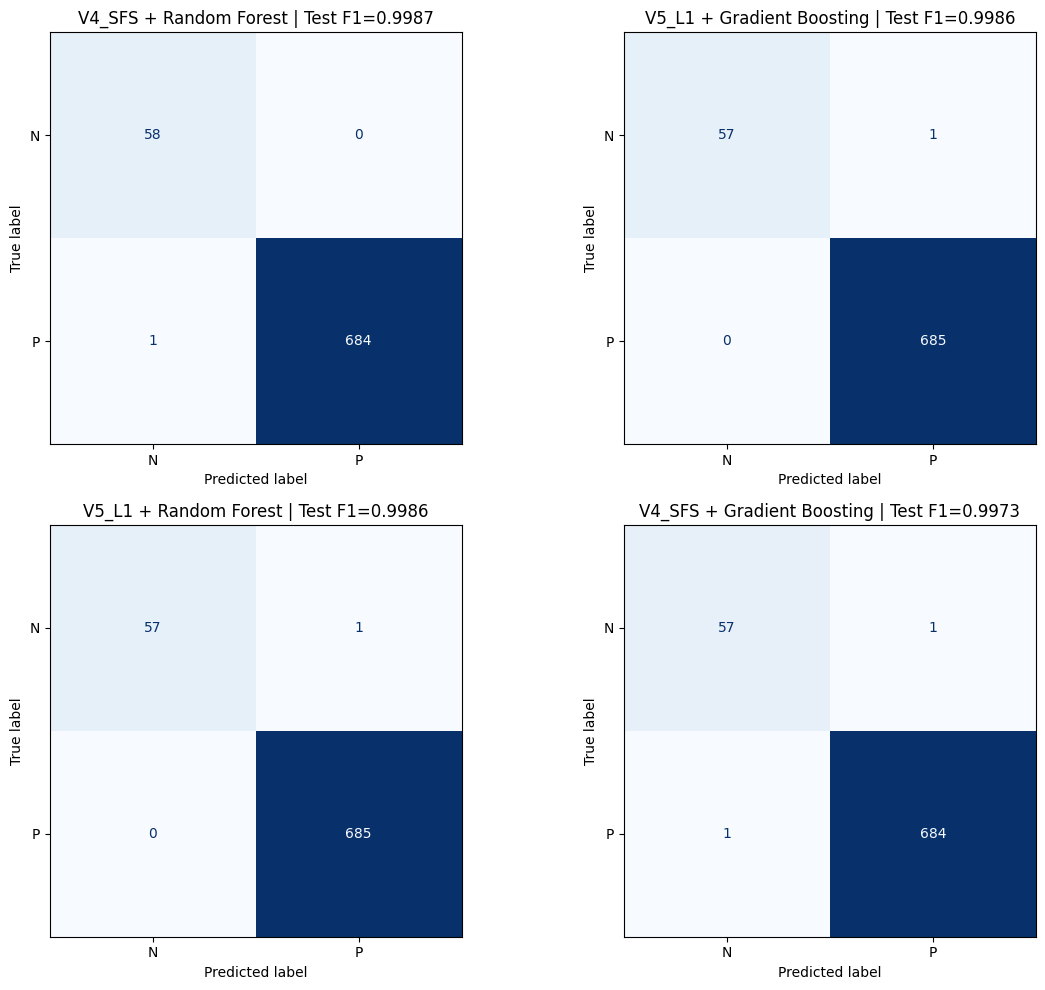

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import math

n_combos = len(final_test_results_df)
ncols = 2
nrows = math.ceil(n_combos / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, final_test_results_df.iterrows()):
    combo_name = row["Pipeline combo"]
    cm = confusion_results[combo_name]["matrix"]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["N", "P"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"{combo_name} | Test F1={row['F1 weighted']:.4f}")

for ax in axes[n_combos:]:
    ax.axis("off")

plt.tight_layout()
plt.show()
